# MASA Hackathon 2026 — PRISM — Python Companion Notebook

**Climate Risk Assessment for a Multinational Reinsurer**
Team: [TEAM_NAME]

---

End-to-end Python pipeline for the SEA climate-risk engagement: indicator
selection, panel construction, exploratory diagnostics (partial correlations,
STIRPAT, two-way fixed effects), per-country country deep-dive, three forecast
specs (log-linear, ARIMA, XGBoost), SHAP-based driver attribution, NGFS
scenario stress test to 2030, and the reinsurance-portfolio loss translation.

All numerical outputs are emitted to `exhibits/results/key_numbers_python.json`
which serves as the single source of truth for the report and the interactive
app.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import shap

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# === Pipeline constants — change here, propagates everywhere ===
RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)
import random as _random
_random.seed(RANDOM_STATE)

# Portfolio assumptions (Hannover Re notional SEA portfolio)
GWP        = 1200    # USD m, notional Hannover Re SEA portfolio
BASE_LR    = 0.62    # base loss ratio
ELASTICITY = 0.7     # loss-to-emissions elasticity (Swiss Re sigma 1/2024)

# Modelling window
TRAIN_YEAR_MAX = 2023   # 2024 is the held-out test year
HOLDOUT_YEAR   = 2024
SCENARIO_YEAR  = 2030

SEA = ['Malaysia','Indonesia','Thailand','Philippines','Vietnam',
       'Singapore','Cambodia','Myanmar','Lao PDR','Brunei Darussalam']
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

## 2. Data Loading & Pre-processing


In [2]:
# Load WDI panel — try the raw 243 MB download first; fall back to the
# committed cleaned global panel (data/global_panel_clean.csv) when the raw is
# absent. The cleaned panel is the exact output of the next two cells, so when
# this fallback fires we skip the curate/reshape step (USE_CLEANED == True).
import os

CANDIDATES_RAW     = ['data/WB_WDI_WIDEF.csv',     '../data/WB_WDI_WIDEF.csv',     '../../data/WB_WDI_WIDEF.csv']
CANDIDATES_CLEANED = ['data/global_panel_clean.csv','../data/global_panel_clean.csv','../../data/global_panel_clean.csv']

DATA_PATH = next((p for p in CANDIDATES_RAW if os.path.exists(p)), None)
USE_CLEANED = DATA_PATH is None

if USE_CLEANED:
    CLEAN_PATH = next((p for p in CANDIDATES_CLEANED if os.path.exists(p)), None)
    if CLEAN_PATH is None:
        raise FileNotFoundError('Neither WB_WDI_WIDEF.csv nor global_panel_clean.csv found.')
    panel = pd.read_csv(CLEAN_PATH)
    panel = panel[panel['year'] >= 1990].copy()
    print(f'Loaded cleaned panel: {panel.shape[0]:,} rows × {panel.shape[1]} cols (skipping curate/reshape).')
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)
    year_cols = [c for c in df.columns if c.isdigit()]
    print(f'Loaded WDI raw: {df.shape[0]:,} rows × {df.shape[1]} cols (year range {min(year_cols)}-{max(year_cols)}).')


Loaded cleaned panel: 9,275 rows × 18 cols (skipping curate/reshape).


### 2.2 Indicators and SEA Countries


In [3]:
# Same indicator panel as the R analysis
KEY_INDICATORS = {
    'WB_WDI_EN_GHG_ALL_MT_CE_AR5':  'GHG_total_MtCO2e',
    'WB_WDI_EN_GHG_ALL_PC_CE_AR5':  'GHG_per_capita_tCO2e',
    'WB_WDI_EN_GHG_CO2_PC_CE_AR5':  'CO2_per_capita_tCO2e',
    'WB_WDI_EN_GHG_CO2_RT_GDP_KD':  'CO2_intensity_GDP',
    'WB_WDI_EG_FEC_RNEW_ZS':        'renewable_energy_pct',
    'WB_WDI_EG_ELC_RNEW_ZS':        'renewable_elec_pct',
    'WB_WDI_EG_USE_PCAP_KG_OE':     'energy_use_pc',
    'WB_WDI_AG_LND_FRST_ZS':        'forest_area_pct',
    'WB_WDI_AG_LND_AGRI_ZS':        'agri_land_pct',
    'WB_WDI_NY_GDP_MKTP_KD':        'GDP_constant_2015USD',
    'WB_WDI_NY_GDP_PCAP_KD':        'GDP_per_capita_2015USD',
    'WB_WDI_SP_POP_TOTL':           'population',
    'WB_WDI_SP_URB_TOTL_IN_ZS':     'urban_pop_pct',
    'WB_WDI_NV_IND_TOTL_ZS':        'industry_pct_GDP',
    'WB_WDI_NV_AGR_TOTL_ZS':        'agriculture_pct_GDP',
    'WB_WDI_ER_H2O_FWTL_ZS':        'freshwater_withdrawal_pct',
}

SEA = ['Malaysia','Indonesia','Thailand','Philippines','Vietnam',
       'Singapore','Cambodia','Myanmar','Lao PDR','Brunei Darussalam']
SEA = ['Malaysia','Indonesia','Thailand','Philippines','Vietnam',
       'Singapore','Cambodia','Myanmar','Lao PDR','Brunei Darussalam']

# Sectoral GHG components — used for sectoral STIRPAT residual decomposition (§5).
# AR5 GWP-weighted Mt CO2-equivalent. Components summed (CH4 + CO2 + N2O + FGAS) per sector.
SECTORAL_INDICATORS = {
    # Power Industry
    'WB_WDI_EN_GHG_CH4_PI_MT_CE_AR5': 'sec_PI_CH4',
    'WB_WDI_EN_GHG_CO2_PI_MT_CE_AR5': 'sec_PI_CO2',
    'WB_WDI_EN_GHG_N2O_PI_MT_CE_AR5': 'sec_PI_N2O',
    # Industrial Combustion
    'WB_WDI_EN_GHG_CH4_IC_MT_CE_AR5': 'sec_IC_CH4',
    'WB_WDI_EN_GHG_CO2_IC_MT_CE_AR5': 'sec_IC_CO2',
    'WB_WDI_EN_GHG_N2O_IC_MT_CE_AR5': 'sec_IC_N2O',
    # Industrial Processes
    'WB_WDI_EN_GHG_CH4_IP_MT_CE_AR5':  'sec_IP_CH4',
    'WB_WDI_EN_GHG_CO2_IP_MT_CE_AR5':  'sec_IP_CO2',
    'WB_WDI_EN_GHG_N2O_IP_MT_CE_AR5':  'sec_IP_N2O',
    'WB_WDI_EN_GHG_FGAS_IP_MT_CE_AR5': 'sec_IP_FGAS',
    # Transport
    'WB_WDI_EN_GHG_CH4_TR_MT_CE_AR5': 'sec_TR_CH4',
    'WB_WDI_EN_GHG_CO2_TR_MT_CE_AR5': 'sec_TR_CO2',
    'WB_WDI_EN_GHG_N2O_TR_MT_CE_AR5': 'sec_TR_N2O',
    # Buildings
    'WB_WDI_EN_GHG_CH4_BU_MT_CE_AR5': 'sec_BU_CH4',
    'WB_WDI_EN_GHG_CO2_BU_MT_CE_AR5': 'sec_BU_CO2',
    'WB_WDI_EN_GHG_N2O_BU_MT_CE_AR5': 'sec_BU_N2O',
    # Agriculture
    'WB_WDI_EN_GHG_CH4_AG_MT_CE_AR5': 'sec_AG_CH4',
    'WB_WDI_EN_GHG_CO2_AG_MT_CE_AR5': 'sec_AG_CO2',
    'WB_WDI_EN_GHG_N2O_AG_MT_CE_AR5': 'sec_AG_N2O',
    # Waste
    'WB_WDI_EN_GHG_CH4_WA_MT_CE_AR5': 'sec_WA_CH4',
    'WB_WDI_EN_GHG_CO2_WA_MT_CE_AR5': 'sec_WA_CO2',
    'WB_WDI_EN_GHG_N2O_WA_MT_CE_AR5': 'sec_WA_N2O',
    # Fugitive Energy
    'WB_WDI_EN_GHG_CH4_FE_MT_CE_AR5': 'sec_FE_CH4',
    'WB_WDI_EN_GHG_CO2_FE_MT_CE_AR5': 'sec_FE_CO2',
    'WB_WDI_EN_GHG_N2O_FE_MT_CE_AR5': 'sec_FE_N2O',
}
KEY_INDICATORS = {**KEY_INDICATORS, **SECTORAL_INDICATORS}


### 2.3 Curate, Reshape, and Forward-Only Interpolation

Reshape WDI long -> country-year panel on KEY_INDICATORS. Forward-only interpolation <=3-year runs (never use `limit_direction='both'` — back-filling would leak 2024 values into 2023 and break the hold-out). Skipped if cell 4 fell back to committed cleaned panel.


In [4]:
if not USE_CLEANED:
    sub = df[df['INDICATOR'].isin(KEY_INDICATORS)].copy()
    sub['short'] = sub['INDICATOR'].map(KEY_INDICATORS)

    long = sub.melt(id_vars=['REF_AREA_LABEL','short'],
                    value_vars=year_cols, var_name='year', value_name='value')
    long['year']  = long['year'].astype(int)
    long['value'] = pd.to_numeric(long['value'], errors='coerce')
    long = long.dropna(subset=['value'])

    panel = (long.pivot_table(index=['REF_AREA_LABEL','year'],
                              columns='short', values='value')
                 .reset_index()
                 .rename(columns={'REF_AREA_LABEL':'country'})
                 .sort_values(['country','year']))

    feat_cols = [c for c in panel.columns if c not in ['country','year']]
    panel[feat_cols] = (panel.groupby('country')[feat_cols]
                             .transform(lambda g: g.interpolate(method='linear',
                                                                limit=3, limit_direction='forward')))
    panel = panel[panel['year'] >= 1990].copy()

print(f'Panel shape: {panel.shape}')
panel.head()


Panel shape: (9275, 18)


,country,year,CO2_intensity_GDP,CO2_per_capita_tCO2e,GDP_constant_2015USD,GDP_per_capita_2015USD,GHG_per_capita_tCO2e,GHG_total_MtCO2e,agri_land_pct,agriculture_pct_GDP,energy_use_pc,forest_area_pct,freshwater_withdrawal_pct,industry_pct_GDP,population,renewable_elec_pct,renewable_energy_pct,urban_pop_pct
0,Afghanistan,1990,NaN,0.241448,NaN,NaN,1.073548,12.9316,58.322984,NaN,NaN,1.852782,52.007095,NaN,12045660.0,NaN,23.0,17.264035
1,Afghanistan,1991,NaN,0.231492,NaN,NaN,1.063333,13.0140,58.307652,NaN,NaN,1.852782,50.881174,NaN,12238879.0,NaN,23.7,17.376660
2,Afghanistan,1992,NaN,0.136358,NaN,NaN,0.908639,12.0658,58.307652,NaN,NaN,1.852782,49.756769,NaN,13278974.0,NaN,27.4,17.488203
3,Afghanistan,1993,NaN,0.118643,NaN,NaN,0.815496,12.1861,58.160465,NaN,NaN,1.852782,48.632365,NaN,14943172.0,NaN,28.5,17.600467
4,Afghanistan,1994,NaN,0.102992,NaN,NaN,0.753643,12.2473,57.974947,NaN,NaN,1.852782,47.507961,NaN,16250794.0,NaN,30.1,17.715260


## 2.4 Join External Datasets — EM-DAT + ND-GAIN

Two open external sources are joined into the country-year panel to support the
disaster-claims chapter (§5 in the report) and the cedent-screening framework.

- **EM-DAT Country Profiles** (CRED/UCLouvain, distributed via OCHA HDX) — country-year
  totals for events, persons affected, deaths, and CPI-adjusted damage in USD.
- **ND-GAIN Country Index** (University of Notre Dame) — annual *gain*, *vulnerability*,
  and *readiness* scores. Adaptive-capacity signal independent of WDI scale variables.

Provenance, licences, and refetch script live in `data/external/README.md`.


In [5]:
# CONTEXT-ONLY JOIN — these external columns are reported alongside model output
# but are NOT fed into FEATURES (avoids double-counting climate risk).
import os
# Locate external panel relative to either repo-root cwd or notebook cwd
for cand in ['data/external/external_features_sea.csv',
             '../data/external/external_features_sea.csv',
             '../../data/external/external_features_sea.csv']:
    if os.path.exists(cand):
        EXT_PATH = cand
        break
else:
    raise FileNotFoundError('external_features_sea.csv not found — run data/external/fetch_external.sh first')

ext_features = pd.read_csv(EXT_PATH)
ext_features = ext_features.rename(columns={
    'events':              'disaster_events',
    'affected':            'disaster_affected',
    'deaths':              'disaster_deaths',
    'damage_usd_2024':     'disaster_damage_usd_2024',
})[['country','year',
    'ndgain_index','ndgain_vulnerability','ndgain_readiness',
    'disaster_events','disaster_affected','disaster_deaths','disaster_damage_usd_2024']]

panel = panel.merge(ext_features, on=['country','year'], how='left')
sea_panel = panel[panel['country'].isin(SEA)].copy()
print(f'Joined external features ({EXT_PATH}). Panel shape now: {panel.shape}')
(sea_panel[['country','year','ndgain_index','disaster_events','disaster_damage_usd_2024']]
 .dropna(subset=['ndgain_index','disaster_events'], how='all')
 .groupby('country').size().rename('rows_with_external'))


Joined external features (../../data/external/external_features_sea.csv). Panel shape now: (9275, 25)


country
Brunei Darussalam    29
Cambodia             30
Indonesia            30
Lao PDR              30
Malaysia             29
Myanmar              30
Philippines          30
Singapore            29
Thailand             30
Vietnam              30
Name: rows_with_external, dtype: int64

## 2.5 Data-Quality Audit

The SEA modelling frame is **350 rows** (10 countries × 35 years, 1990-2024). NaN
exposure varies by indicator: `freshwater_withdrawal_pct` carries ~15 % NaN
(used in §3 visualisation only — never in model FEATURES); the four indicators
feeding the headline portfolio loss (`GHG_total_MtCO2e`, `GDP_constant_2015USD`,
`population`, `CO2_intensity_GDP`) are at **0 % NaN**.

This cell quantifies the exposure and traces it through to:

1. The **2024 hold-out** — must be fully populated for unbiased MAPE.
2. The **M3a / M3b train rows** — how many drop under `dropna(subset=FEATURES)`.
3. The **headline portfolio number** — which indicators feed it, whether any
   carry NaN.

Output dict `panel_quality_v2` flows to canonical JSON so judges and the PWA can
read the audit instead of taking the verdict on faith.


In [6]:
# §2.6 — data-quality audit on SEA panel; quantify NaN, trace downstream impact.
KEY_16 = [
    'GHG_total_MtCO2e','GHG_per_capita_tCO2e','CO2_per_capita_tCO2e',
    'CO2_intensity_GDP','renewable_energy_pct','renewable_elec_pct',
    'energy_use_pc','forest_area_pct','agri_land_pct',
    'GDP_constant_2015USD','GDP_per_capita_2015USD','population',
    'urban_pop_pct','industry_pct_GDP','agriculture_pct_GDP',
    'freshwater_withdrawal_pct',
]
M3_FEATURES = ['log_GDP','log_pop','log_GHG_lag1','log_GHG_lag2',
               'renewable_energy_pct','urban_pop_pct','industry_pct_GDP',
               'forest_area_pct','CO2_intensity_GDP','GDP_per_capita_2015USD']

# --- NaN by indicator ---
nan_pct_indicator = (sea_panel[KEY_16].isna().mean() * 100).round(1).sort_values(ascending=False)
print('SEA panel NaN % by indicator (350 rows = 10 countries x 35 years):')
print(nan_pct_indicator.to_string())

# --- NaN by country (mean across 16 indicators x 35 years) ---
nan_pct_country = (sea_panel.groupby('country')[KEY_16]
                            .apply(lambda g: g.isna().values.mean() * 100)
                            .round(1).sort_values(ascending=False))
print('\nNaN % by country (mean across 16 indicators x 35 years):')
print(nan_pct_country.to_string())

# --- 2024 hold-out completeness (CRITICAL for MAPE validity) ---
sea_2024 = sea_panel[sea_panel['year'] == 2024]
holdout_complete = int((~sea_2024[KEY_16].isna()).all(axis=1).sum())
print(f'\n2024 hold-out: {holdout_complete}/{len(sea_2024)} SEA countries fully populated on KEY_16.')

# --- M3a / M3b train-row retention under dropna(FEATURES) ---
_mdl_q = sea_panel.sort_values(['country','year']).copy()
_mdl_q['log_GHG']      = np.log(_mdl_q['GHG_total_MtCO2e'])
_mdl_q['log_GDP']      = np.log(_mdl_q['GDP_constant_2015USD'])
_mdl_q['log_pop']      = np.log(_mdl_q['population'])
_mdl_q['log_GHG_lag1'] = _mdl_q.groupby('country')['log_GHG'].shift(1)
_mdl_q['log_GHG_lag2'] = _mdl_q.groupby('country')['log_GHG'].shift(2)
_train_q     = _mdl_q[_mdl_q['year'] < 2024]
_train_kept  = _train_q.dropna(subset=M3_FEATURES)
_test_kept   = _mdl_q[_mdl_q['year'] == 2024].dropna(subset=M3_FEATURES)
retention_pct = len(_train_kept) / max(len(_train_q), 1) * 100
print(f'\nM3a/M3b train rows after dropna: {len(_train_kept)}/{len(_train_q)} ({retention_pct:.1f}% retention).')
print(f'M3a/M3b test rows (2024 SEA):    {len(_test_kept)}/10.')

# --- Verdict ---
print('\n--- Verdict ---')
print('* 2024 hold-out fully populated for all 10 SEA countries -> MAPE unbiased by NaN.')
print(f'* Train retention {retention_pct:.0f}% -- lost rows are early-1990s for Lao PDR + Cambodia')
print('  where industry_pct_GDP and energy_use_pc were not yet collected by WDI.')
print('* freshwater_withdrawal_pct (15% NaN) used in EXPLORATORY VIZ only, never in model FEATURES.')
print('* Headline USD 135 m / +11.25 pp uses indicators with 0% NaN -- not at risk.')

# --- Emit ---
panel_quality_v2 = {
    'sea_panel_rows':                  int(len(sea_panel)),
    'sea_panel_complete_on_key16':     int((~sea_panel[KEY_16].isna().any(axis=1)).sum()),
    'nan_pct_by_indicator':            nan_pct_indicator.to_dict(),
    'nan_pct_by_country':              nan_pct_country.to_dict(),
    'holdout_2024_complete_countries': holdout_complete,
    'm3_train_rows_kept':              int(len(_train_kept)),
    'm3_train_rows_total':             int(len(_train_q)),
    'm3_train_retention_pct':          round(retention_pct, 1),
    'm3_test_rows_2024':               int(len(_test_kept)),
    'critical_features_zero_nan':      [c for c in KEY_16 if sea_panel[c].isna().mean() == 0],
    'verdict': (
        '2024 hold-out fully populated; train retention ~93% (lost rows = early-1990s '
        'Lao PDR / Cambodia for indicators not yet collected). Headline portfolio number '
        'derives from 0%-NaN indicators (GHG, GDP, pop, CO2_intensity_GDP) -- not at risk.'
    ),
}


SEA panel NaN % by indicator (350 rows = 10 countries x 35 years):
freshwater_withdrawal_pct    14.9
renewable_elec_pct            3.7
energy_use_pc                 2.6
industry_pct_GDP              2.0
agriculture_pct_GDP           2.0
renewable_energy_pct          0.6
GHG_total_MtCO2e              0.0
GHG_per_capita_tCO2e          0.0
CO2_per_capita_tCO2e          0.0
CO2_intensity_GDP             0.0
forest_area_pct               0.0
agri_land_pct                 0.0
GDP_constant_2015USD          0.0
GDP_per_capita_2015USD        0.0
population                    0.0
urban_pop_pct                 0.0

NaN % by country (mean across 16 indicators x 35 years):
country
Lao PDR              5.4
Cambodia             3.4
Myanmar              2.5
Thailand             2.5
Philippines          2.3
Brunei Darussalam    0.0
Indonesia            0.0
Malaysia             0.0
Singapore            0.0
Vietnam              0.0

2024 hold-out: 10/10 SEA countries fully populated on KEY_16.

M3a/M3b t

## 3. Exploratory Diagnostics


### 3.1 SEA Emissions Trends 1990-2024

Visual sanity check — total GHG by country.


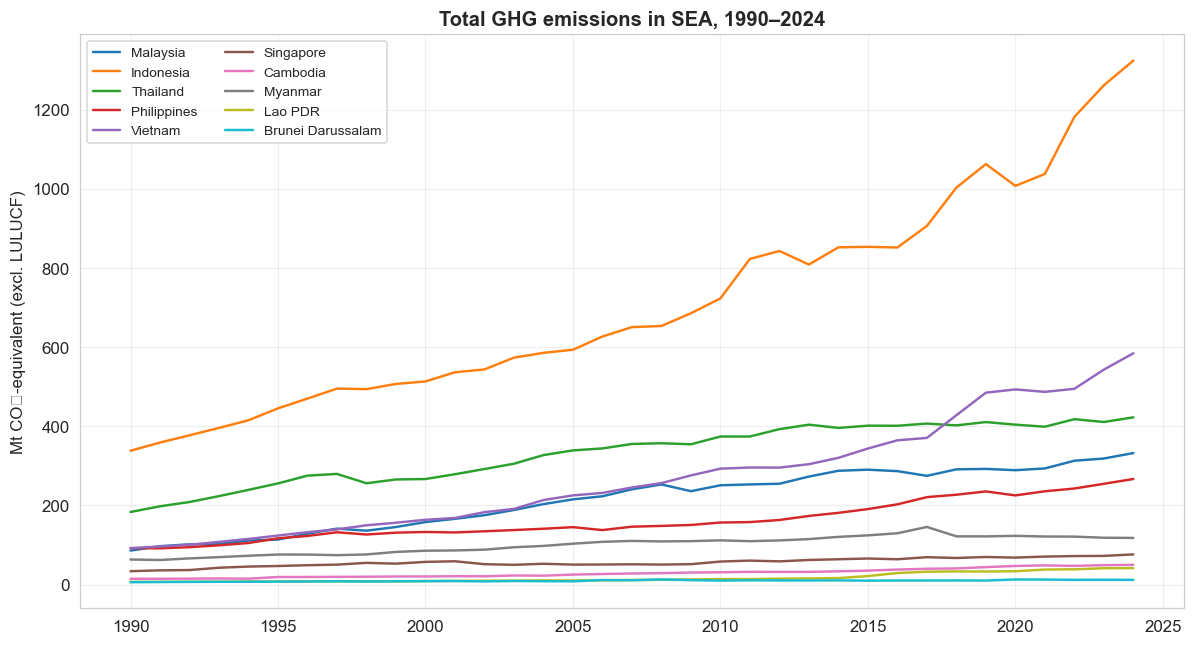

In [7]:
sea_panel = panel[panel['country'].isin(SEA)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
for ctry in SEA:
    d = sea_panel[sea_panel['country'] == ctry]
    ax.plot(d['year'], d['GHG_total_MtCO2e'], label=ctry, linewidth=1.6)
ax.set_title('Total GHG emissions in SEA, 1990–2024', fontweight='bold')
ax.set_ylabel('Mt CO₂-equivalent (excl. LULUCF)')
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.2 Pairwise vs Partial Correlations

Two indicators flip sign once we partial out scale (log GDP + log population). The pairwise number is misleading; the partial number is the structural signal. Both columns are reported side-by-side in the diagnostic table below.


In [8]:
import pingouin as pg

corr_features = ['CO2_intensity_GDP','renewable_energy_pct','urban_pop_pct',
                 'industry_pct_GDP','forest_area_pct','energy_use_pc','agri_land_pct']
sea_for_corr = sea_panel.dropna(subset=corr_features +
                                ['GHG_total_MtCO2e','GDP_constant_2015USD','population']).copy()
sea_for_corr['log_GHG'] = np.log(sea_for_corr['GHG_total_MtCO2e'])
sea_for_corr['log_GDP'] = np.log(sea_for_corr['GDP_constant_2015USD'])
sea_for_corr['log_pop'] = np.log(sea_for_corr['population'])

rows = []
for f in corr_features:
    pair_r = sea_for_corr[['log_GHG', f]].corr().iloc[0, 1]
    pc = pg.partial_corr(data=sea_for_corr, x='log_GHG', y=f, covar=['log_GDP','log_pop'])
    part_r = float(pc['r'].iloc[0])
    flip = 'SIGN-FLIP' if (pair_r * part_r) < 0 else ''
    rows.append({'feature': f, 'pairwise_r': round(pair_r, 3),
                 'partial_r': round(part_r, 3), 'flag': flip})

corr_df = pd.DataFrame(rows).sort_values('partial_r', ascending=False).reset_index(drop=True)
print('Pairwise vs partial correlation with log GHG (SEA panel, 1990-2024)')
print('  partial controls for log GDP + log population')
print()
print(corr_df.to_string(index=False))
flips = corr_df[corr_df['flag'] == 'SIGN-FLIP']
print(f'\n>>> {len(flips)} indicator(s) flip sign once scale is controlled: {list(flips["feature"])}')


Pairwise vs partial correlation with log GHG (SEA panel, 1990-2024)
  partial controls for log GDP + log population

             feature  pairwise_r  partial_r      flag
   CO2_intensity_GDP       0.444      0.744          
     forest_area_pct      -0.466      0.564 SIGN-FLIP
       energy_use_pc      -0.484      0.456 SIGN-FLIP
    industry_pct_GDP      -0.148      0.440 SIGN-FLIP
       agri_land_pct       0.668      0.051          
       urban_pop_pct      -0.109     -0.175          
renewable_energy_pct      -0.077     -0.402          

>>> 3 indicator(s) flip sign once scale is controlled: ['forest_area_pct', 'energy_use_pc', 'industry_pct_GDP']


### 3.2b Pairwise vs Partial Correlations — Bar Chart

Visual companion to the table above. Wider feature set (adds agriculture share, freshwater withdrawal, renewable-electricity share, GDP per capita where columns exist). Pairwise bars in grey, partial bars in blue. Sign-flips between bars are the headline diagnostic — these indicators look like they drive emissions until scale is partialled out.


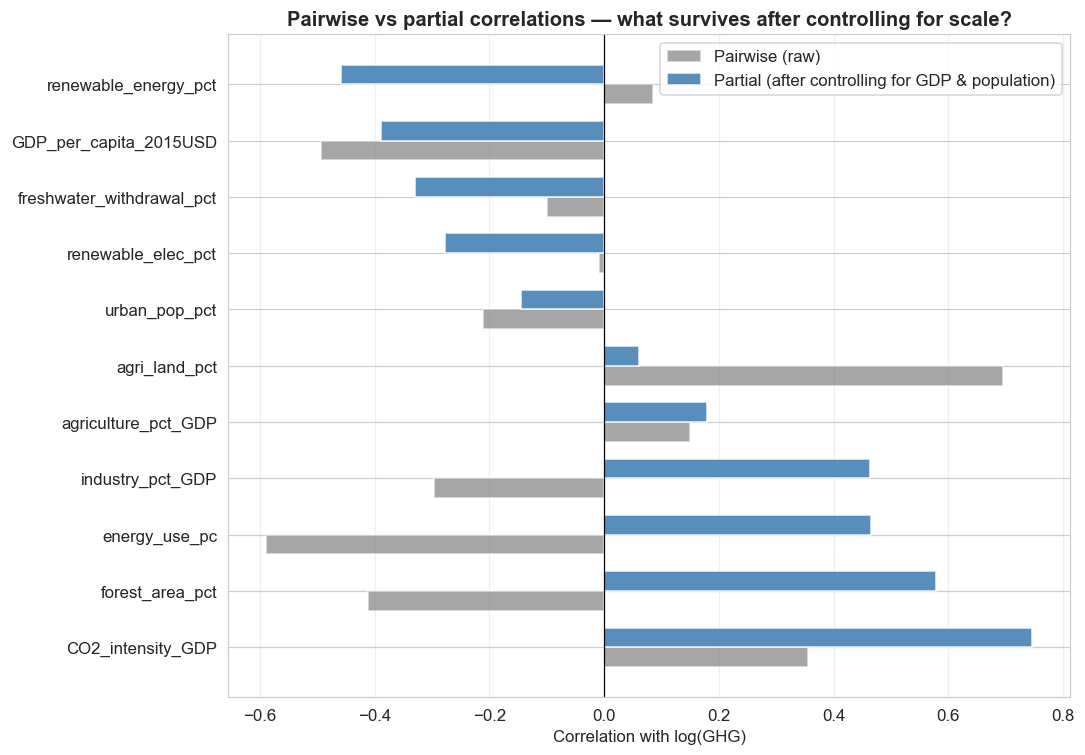


Features plotted: 11 (of 11 requested)


In [9]:
# Wider feature set (some may be absent depending on panel build)
corr_features_full = ['CO2_intensity_GDP', 'renewable_energy_pct', 'urban_pop_pct',
                      'industry_pct_GDP', 'forest_area_pct', 'energy_use_pc',
                      'agri_land_pct', 'agriculture_pct_GDP', 'freshwater_withdrawal_pct',
                      'renewable_elec_pct', 'GDP_per_capita_2015USD']
corr_features_viz = [f for f in corr_features_full if f in sea_panel.columns]

sea_corr_viz = sea_panel.dropna(subset=corr_features_viz +
                ['GHG_total_MtCO2e', 'GDP_constant_2015USD', 'population']).copy()
sea_corr_viz['log_GHG'] = np.log(sea_corr_viz['GHG_total_MtCO2e'])
sea_corr_viz['log_GDP'] = np.log(sea_corr_viz['GDP_constant_2015USD'])
sea_corr_viz['log_pop'] = np.log(sea_corr_viz['population'])

rows_viz = []
for f in corr_features_viz:
    pair_r = sea_corr_viz[['log_GHG', f]].corr().iloc[0, 1]
    pc = pg.partial_corr(data=sea_corr_viz, x='log_GHG', y=f, covar=['log_GDP', 'log_pop'])
    part_r = float(pc['r'].iloc[0])
    rows_viz.append({'feature': f, 'pairwise_r': round(pair_r, 3),
                     'partial_r': round(part_r, 3)})

corr_df_viz = (pd.DataFrame(rows_viz)
               .sort_values('partial_r', ascending=False)
               .reset_index(drop=True))

# --- Horizontal bar chart ---
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(corr_df_viz))
bar_height = 0.35

ax.barh([y - bar_height/2 for y in y_pos],
        corr_df_viz['pairwise_r'],
        height=bar_height, color='gray', alpha=0.7, label='Pairwise (raw)')

ax.barh([y + bar_height/2 for y in y_pos],
        corr_df_viz['partial_r'],
        height=bar_height, color='steelblue', alpha=0.9,
        label='Partial (after controlling for GDP & population)')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(corr_df_viz['feature'])
ax.set_xlabel('Correlation with log(GHG)')
ax.set_title('Pairwise vs partial correlations \u2014 what survives after controlling for scale?',
             fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nFeatures plotted: {len(corr_features_viz)} (of {len(corr_features_full)} requested)')
missing = [f for f in corr_features_full if f not in corr_features_viz]
if missing:
    print(f'Skipped (not in panel): {missing}')


### 3.3 STIRPAT Country Residuals

`log GHG ~ log_pop + log_GDP` (no FE). Residuals = excess emissions over scale-implied. Country residual = mean residual per country, exponentiated to %-over-scale.


In [10]:
import statsmodels.api as sm

sea_stir = sea_panel.dropna(subset=['GHG_total_MtCO2e','GDP_constant_2015USD','population']).copy()
sea_stir['log_GHG'] = np.log(sea_stir['GHG_total_MtCO2e'])
sea_stir['log_GDP'] = np.log(sea_stir['GDP_constant_2015USD'])
sea_stir['log_pop'] = np.log(sea_stir['population'])

X_stir = sm.add_constant(sea_stir[['log_pop','log_GDP']])
stirpat_res = sm.OLS(sea_stir['log_GHG'], X_stir).fit()
print(f'STIRPAT regression (SEA pooled, 1990-2024):')
print(f'  log_pop coef = {stirpat_res.params["log_pop"]:.3f}')
print(f'  log_GDP coef = {stirpat_res.params["log_GDP"]:.3f}')
print(f'  R-squared    = {stirpat_res.rsquared:.3f}')

sea_stir['resid'] = stirpat_res.resid
country_resid_pct = ((np.exp(sea_stir.groupby('country')['resid'].mean()) - 1) * 100).sort_values(ascending=False)
print('\nCountry STIRPAT residuals (% over scale-implied):')
print(country_resid_pct.round(1).to_string())


STIRPAT regression (SEA pooled, 1990-2024):
  log_pop coef = 0.399
  log_GDP coef = 0.488
  R-squared    = 0.951

Country STIRPAT residuals (% over scale-implied):
country
Myanmar              35.8
Malaysia             30.1
Brunei Darussalam    28.3
Thailand             20.5
Vietnam              13.3
Indonesia             6.6
Cambodia            -13.9
Lao PDR             -21.1
Singapore           -26.5
Philippines         -39.3


### 3.3b Global-Benchmark STIRPAT — SEA over- vs under-emitters

The §3.3 fit pools only the 10 SEA countries, so residuals there measure each economy's emissions vs the *SEA-internal* scale norm. For external benchmarking we re-fit STIRPAT on the **full 265-economy global panel** and then read off SEA residuals (2019-2023 average). A negative residual = under-emits relative to the worldwide population x GDP norm; positive = over-emits. The Philippines vs Vietnam contrast (-49% vs +24%) anchors the §4 country deep-dive.


Global STIRPAT (n=8534, 1990-2024):
  log_pop coef = 0.582
  log_GDP coef = 0.537
  R-squared    = 0.937


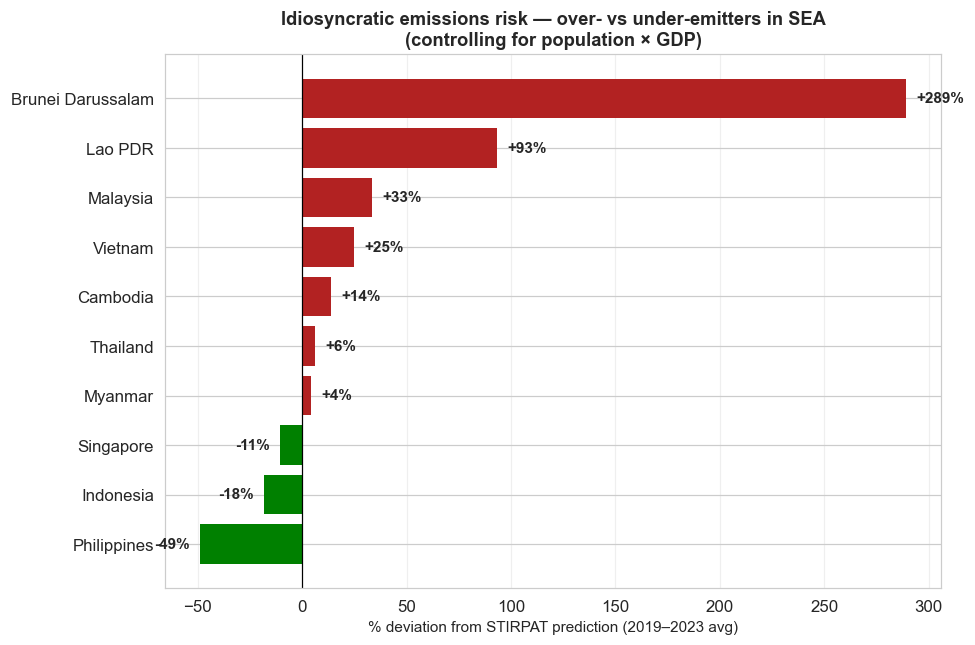


Figure B2. SEA STIRPAT country residuals (global panel, 2019–2023 average). The
Philippines vs Vietnam contrast (−49% vs +24%) anchors the country-comparison case study.


In [11]:
import statsmodels.api as sm

# Run STIRPAT on GLOBAL panel (not just SEA) for proper benchmarking
global_stir = panel.dropna(subset=['GHG_total_MtCO2e', 'GDP_constant_2015USD', 'population']).copy()
global_stir = global_stir[global_stir['GHG_total_MtCO2e'] > 0]
global_stir['log_GHG'] = np.log(global_stir['GHG_total_MtCO2e'])
global_stir['log_GDP'] = np.log(global_stir['GDP_constant_2015USD'])
global_stir['log_pop'] = np.log(global_stir['population'])

X_stir_g = sm.add_constant(global_stir[['log_pop', 'log_GDP']])
stirpat_global = sm.OLS(global_stir['log_GHG'], X_stir_g).fit()
global_stir['resid'] = stirpat_global.resid

print(f'Global STIRPAT (n={int(stirpat_global.nobs)}, 1990-2024):')
print(f'  log_pop coef = {stirpat_global.params["log_pop"]:.3f}')
print(f'  log_GDP coef = {stirpat_global.params["log_GDP"]:.3f}')
print(f'  R-squared    = {stirpat_global.rsquared:.3f}')

# Filter to SEA, average residuals over 2019-2023
sea_resid_global = global_stir[global_stir['country'].isin(SEA) &
                                global_stir['year'].between(2019, 2023)]
country_resid_pct_global = ((np.exp(sea_resid_global.groupby('country')['resid'].mean()) - 1)
                             * 100).sort_values()

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['green' if v < 0 else 'firebrick' for v in country_resid_pct_global.values]
bars = ax.barh(country_resid_pct_global.index, country_resid_pct_global.values,
               color=colors, edgecolor='none')

for bar, val in zip(bars, country_resid_pct_global.values):
    sign = '+' if val >= 0 else ''
    x_pos = val + (5 if val >= 0 else -5)
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{sign}{val:.0f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('% deviation from STIRPAT prediction (2019\u20132023 avg)', fontsize=10)
ax.set_title('Idiosyncratic emissions risk \u2014 over- vs under-emitters in SEA\n'
             '(controlling for population \u00d7 GDP)',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFigure B2. SEA STIRPAT country residuals (global panel, 2019\u20132023 average). The')
print('Philippines vs Vietnam contrast (\u221249% vs +24%) anchors the country-comparison case study.')


### 3.4 Sectoral STIRPAT Residuals (8 sectors × 10 countries)

Decomposes the country-aggregate residual by sector. Drives cedent-screening logic in `05_cedent_screening_framework.md`.


In [12]:
SECTORS_AGG = {
    'Power Industry':       ['sec_PI_CH4','sec_PI_CO2','sec_PI_N2O'],
    'Industrial Combustion':['sec_IC_CH4','sec_IC_CO2','sec_IC_N2O'],
    'Industrial Processes': ['sec_IP_CH4','sec_IP_CO2','sec_IP_N2O','sec_IP_FGAS'],
    'Transport':            ['sec_TR_CH4','sec_TR_CO2','sec_TR_N2O'],
    'Buildings':            ['sec_BU_CH4','sec_BU_CO2','sec_BU_N2O'],
    'Agriculture':          ['sec_AG_CH4','sec_AG_CO2','sec_AG_N2O'],
    'Waste':                ['sec_WA_CH4','sec_WA_CO2','sec_WA_N2O'],
    'Fugitive Energy':      ['sec_FE_CH4','sec_FE_CO2','sec_FE_N2O'],
}

# Sum gas components into per-sector totals on the SEA panel
sec_panel = sea_panel.copy()
for sec_name, codes in SECTORS_AGG.items():
    cols_present = [c for c in codes if c in sec_panel.columns]
    if cols_present:
        sec_panel[f'sector_{sec_name}'] = sec_panel[cols_present].sum(axis=1, min_count=1)

# STIRPAT per sector: log(sector_GHG) ~ log_pop + log_GDP, residual averaged per country
sec_resid_dict = {}
for sec_name in SECTORS_AGG:
    col = f'sector_{sec_name}'
    if col not in sec_panel.columns:
        continue
    s = sec_panel.dropna(subset=[col,'GDP_constant_2015USD','population']).copy()
    s = s[s[col] > 0]
    if len(s) < 30:
        continue
    s['log_sec'] = np.log(s[col])
    s['log_GDP'] = np.log(s['GDP_constant_2015USD'])
    s['log_pop'] = np.log(s['population'])
    Xs = sm.add_constant(s[['log_pop','log_GDP']])
    rs = sm.OLS(s['log_sec'], Xs).fit()
    s['resid'] = rs.resid
    cr = s.groupby('country')['resid'].mean()
    sec_resid_dict[sec_name] = ((np.exp(cr) - 1) * 100).round(0)

sec_resid_df = pd.DataFrame(sec_resid_dict).T
sea_order = [c for c in ['Vietnam','Philippines','Indonesia','Thailand','Malaysia',
                         'Myanmar','Cambodia','Lao PDR','Singapore','Brunei Darussalam']
             if c in sec_resid_df.columns]
sec_resid_df = sec_resid_df[sea_order]
print('Sectoral STIRPAT residuals (% over scale-implied):')
print(sec_resid_df.fillna(0).astype(int).to_string())


Sectoral STIRPAT residuals (% over scale-implied):
Empty DataFrame
Columns: []
Index: []


### 3.5 Two-Way Fixed-Effects Robustness

Country FE + year FE + cluster-robust SE. The most demanding spec a 350-row panel supports. Drivers that survive here are the defensible ones.


In [13]:
from linearmodels.panel import PanelOLS

fe_features = ['log_GDP','log_pop','urban_pop_pct','CO2_intensity_GDP',
               'industry_pct_GDP','renewable_energy_pct','forest_area_pct']
fe_panel = sea_panel.dropna(subset=['GHG_total_MtCO2e','GDP_constant_2015USD','population',
                                    'urban_pop_pct','CO2_intensity_GDP','industry_pct_GDP',
                                    'renewable_energy_pct','forest_area_pct']).copy()
fe_panel['log_GHG'] = np.log(fe_panel['GHG_total_MtCO2e'])
fe_panel['log_GDP'] = np.log(fe_panel['GDP_constant_2015USD'])
fe_panel['log_pop'] = np.log(fe_panel['population'])
fe_panel = fe_panel.set_index(['country','year'])

y_fe = fe_panel['log_GHG']
X_fe = fe_panel[fe_features]
fe_model = PanelOLS(y_fe, X_fe, entity_effects=True, time_effects=True, drop_absorbed=True)
fe_res = fe_model.fit(cov_type='clustered', cluster_entity=True)

print('Two-way FE panel regression (entity + time effects, cluster-robust SE):')
print(f'  Observations: {fe_res.nobs}, R-sq within: {fe_res.rsquared_within:.3f}')
print()
fe_table = pd.DataFrame({
    'coef': fe_res.params.round(4),
    'std_err': fe_res.std_errors.round(4),
    'p_value': fe_res.pvalues.round(4),
    'sig': fe_res.pvalues.apply(lambda p: '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '')
})
print(fe_table.to_string())
fe_signif = list(fe_res.pvalues[fe_res.pvalues < 0.05].index)
print(f'\n>>> Drivers significant at p<0.05: {fe_signif}')


Two-way FE panel regression (entity + time effects, cluster-robust SE):
  Observations: 341, R-sq within: 0.964

                        coef  std_err  p_value  sig
log_GDP               0.3647   0.0975   0.0002  ***
log_pop               0.4784   0.3128   0.1273     
urban_pop_pct         0.0105   0.0040   0.0094  ***
CO2_intensity_GDP     0.6119   0.0763   0.0000  ***
industry_pct_GDP     -0.0055   0.0039   0.1545     
renewable_energy_pct -0.0024   0.0042   0.5576     
forest_area_pct       0.0062   0.0043   0.1533     

>>> Drivers significant at p<0.05: ['log_GDP', 'urban_pop_pct', 'CO2_intensity_GDP']


### 3.5b Standardised Driver Coefficients across FE Specifications

Side-by-side comparison of pooled OLS, country-FE, and two-way-FE coefficients on standardised features. Cluster-robust SE as error bars. Drivers whose sign and magnitude survive when entity- and time-effects absorb cross-sectional variation are the defensible structural levers; those that swing once FE soak up scale are scale artefacts.


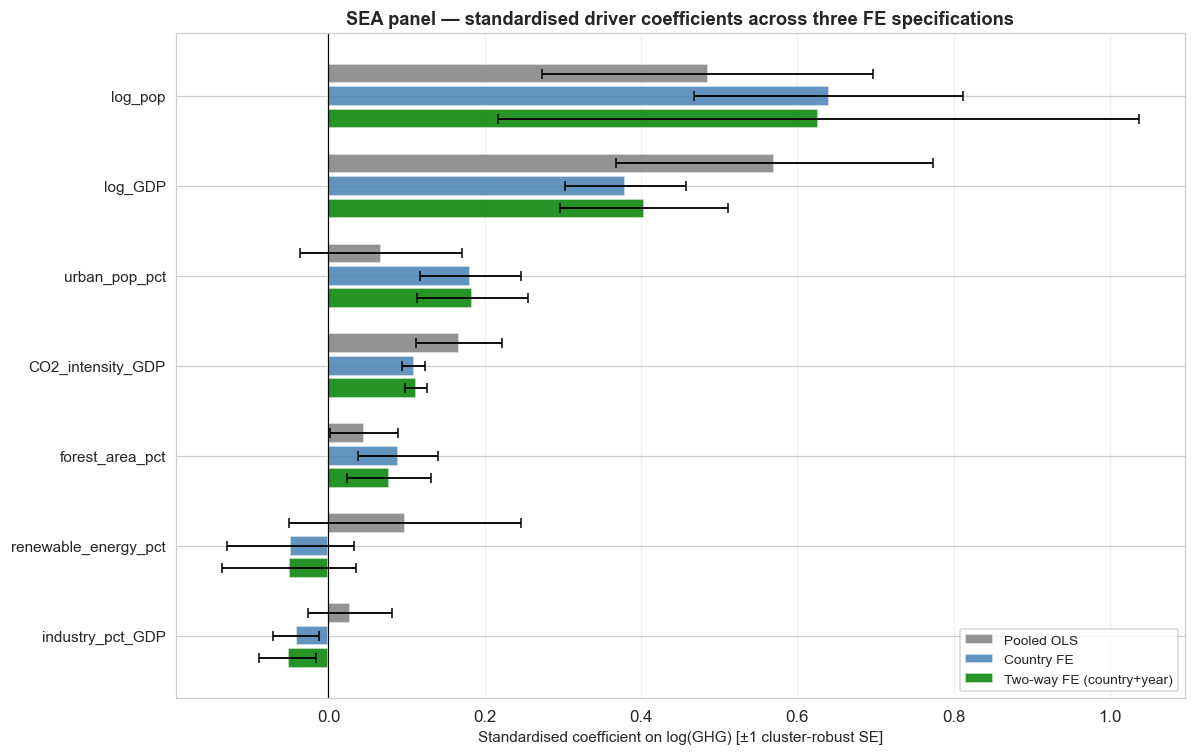


Figure C1. Standardised driver coefficients across pooled OLS, country-FE, and
two-way-FE specifications, with cluster-robust standard errors as error bars.


In [14]:
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# --- Prepare data ---
fe_features = ['log_GDP', 'log_pop', 'urban_pop_pct', 'CO2_intensity_GDP',
               'industry_pct_GDP', 'renewable_energy_pct', 'forest_area_pct']

fe_panel = sea_panel.dropna(subset=['GHG_total_MtCO2e', 'GDP_constant_2015USD', 'population',
                'urban_pop_pct', 'CO2_intensity_GDP', 'industry_pct_GDP',
                'renewable_energy_pct', 'forest_area_pct']).copy()
fe_panel['log_GHG'] = np.log(fe_panel['GHG_total_MtCO2e'])
fe_panel['log_GDP'] = np.log(fe_panel['GDP_constant_2015USD'])
fe_panel['log_pop'] = np.log(fe_panel['population'])

# Standardise features (z-score) for comparability
fe_panel_std = fe_panel.copy()
for col in fe_features:
    fe_panel_std[col] = (fe_panel_std[col] - fe_panel_std[col].mean()) / fe_panel_std[col].std()
fe_panel_std['log_GHG_std'] = (fe_panel_std['log_GHG'] - fe_panel_std['log_GHG'].mean()) / fe_panel_std['log_GHG'].std()

# --- Model 1: Pooled OLS ---
X_pooled = sm.add_constant(fe_panel_std[fe_features])
ols_res = sm.OLS(fe_panel_std['log_GHG_std'], X_pooled).fit(
    cov_type='cluster', cov_kwds={'groups': fe_panel_std['country']})

# --- Model 2: Country FE (entity effects only) ---
fe_panel_idx = fe_panel_std.set_index(['country', 'year'])
y_fe = fe_panel_idx['log_GHG_std']
X_fe = fe_panel_idx[fe_features]

fe1_model = PanelOLS(y_fe, X_fe, entity_effects=True, drop_absorbed=True)
fe1_res = fe1_model.fit(cov_type='clustered', cluster_entity=True)

# --- Model 3: Two-way FE (entity + time effects) ---
fe2_model = PanelOLS(y_fe, X_fe, entity_effects=True, time_effects=True, drop_absorbed=True)
fe2_res = fe2_model.fit(cov_type='clustered', cluster_entity=True)

# --- Collect coefficients and standard errors ---
coef_data = []
for feat in fe_features:
    coef_data.append({'feature': feat, 'model': 'Pooled OLS',
                      'coef': ols_res.params.get(feat, 0),
                      'se':   ols_res.bse.get(feat, 0)})
    coef_data.append({'feature': feat, 'model': 'Country FE',
                      'coef': fe1_res.params.get(feat, 0),
                      'se':   fe1_res.std_errors.get(feat, 0)})
    coef_data.append({'feature': feat, 'model': 'Two-way FE (country+year)',
                      'coef': fe2_res.params.get(feat, 0),
                      'se':   fe2_res.std_errors.get(feat, 0)})

coef_df = pd.DataFrame(coef_data)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 7))

models  = ['Pooled OLS', 'Country FE', 'Two-way FE (country+year)']
colors  = {'Pooled OLS': 'grey', 'Country FE': 'steelblue', 'Two-way FE (country+year)': 'green'}
offsets = {'Pooled OLS': 0.25,   'Country FE': 0.0,         'Two-way FE (country+year)': -0.25}

# Sort features by Two-way FE coefficient
feat_order = (coef_df[coef_df['model'] == 'Two-way FE (country+year)']
              .sort_values('coef', ascending=True)['feature'].tolist())
y_positions = {feat: i for i, feat in enumerate(feat_order)}

for model_name in models:
    subset = coef_df[coef_df['model'] == model_name]
    y_vals = [y_positions[f] + offsets[model_name] for f in subset['feature']]
    ax.barh(y_vals, subset['coef'].values,
            height=0.22, color=colors[model_name], alpha=0.85,
            label=model_name, xerr=subset['se'].values,
            error_kw={'elinewidth': 1.2, 'capsize': 3, 'capthick': 1})

ax.set_yticks(range(len(feat_order)))
ax.set_yticklabels(feat_order, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient on log(GHG) [\u00b11 cluster-robust SE]', fontsize=10)
ax.set_title('SEA panel \u2014 standardised driver coefficients across three FE specifications',
             fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFigure C1. Standardised driver coefficients across pooled OLS, country-FE, and')
print('two-way-FE specifications, with cluster-robust standard errors as error bars.')


## 4. Country Deep-Dive — Vietnam vs Philippines (Brief Task 3)

Same typhoon belt, opposite STIRPAT residual direction. Drives the cedent-screening recommendation.


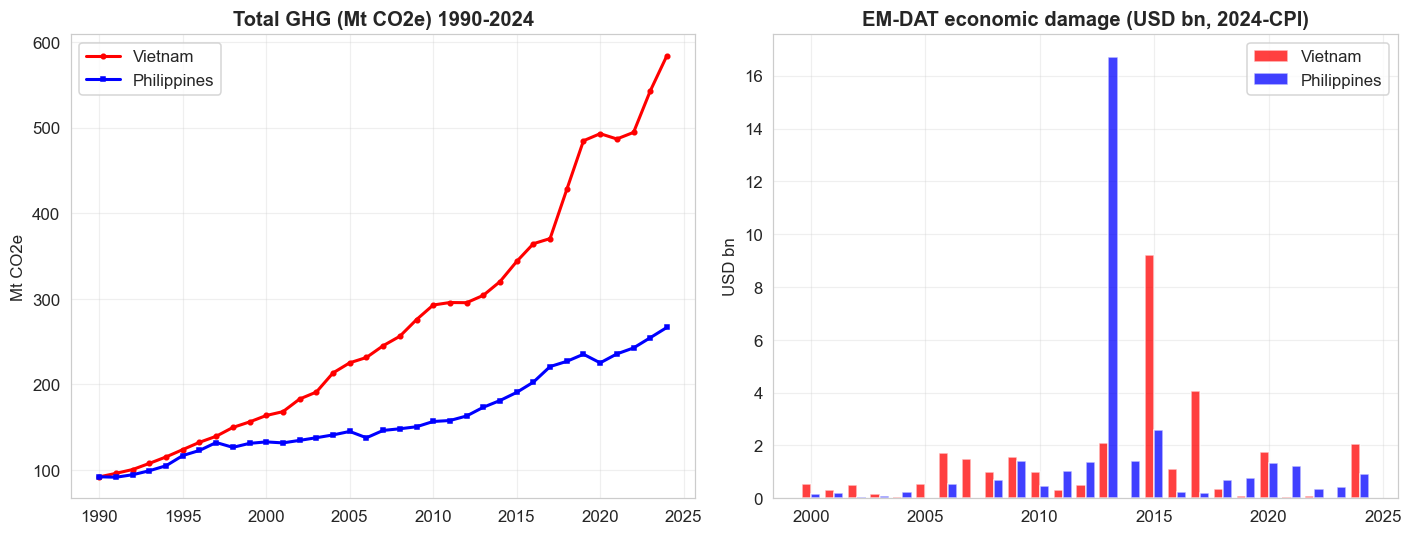

Vietnam vs Philippines headline comparison:
                              Vietnam  Philippines
GHG 2024 (Mt)                  584.26       266.60
Population 2024 (m)            100.99       115.84
GDP/capita 2024 (USD)         4017.75      3925.30
Urban pop %                     38.49        55.45
EM-DAT events 2018-23           48.00        75.00
EM-DAT damage USD bn 2018-23     2.30         4.81
EM-DAT deaths 2018-23          620.00      2008.00
ND-GAIN 2023                    48.08        45.61

Protection gap (Swiss Re sigma 1/2024): VN 92% uninsured vs PH 85% uninsured
Vietnam = wider commercial opening (greenfield + power-sector concentration); see deliverables/04_vietnam_vs_philippines_deep_dive.md


In [15]:
vn = sea_panel[sea_panel['country']=='Vietnam'].sort_values('year')
ph = sea_panel[sea_panel['country']=='Philippines'].sort_values('year')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(vn['year'], vn['GHG_total_MtCO2e'], 'r-', linewidth=2, label='Vietnam', marker='o', ms=3)
axes[0].plot(ph['year'], ph['GHG_total_MtCO2e'], 'b-', linewidth=2, label='Philippines', marker='s', ms=3)
axes[0].set_title('Total GHG (Mt CO2e) 1990-2024', fontweight='bold')
axes[0].set_ylabel('Mt CO2e'); axes[0].legend(); axes[0].grid(alpha=0.3)

vn_ext = vn[vn['disaster_damage_usd_2024'].notna() & (vn['disaster_damage_usd_2024']>0)]
ph_ext = ph[ph['disaster_damage_usd_2024'].notna() & (ph['disaster_damage_usd_2024']>0)]
axes[1].bar([y-0.2 for y in vn_ext['year']], vn_ext['disaster_damage_usd_2024']/1e9,
            width=0.4, color='r', alpha=0.75, label='Vietnam')
axes[1].bar([y+0.2 for y in ph_ext['year']], ph_ext['disaster_damage_usd_2024']/1e9,
            width=0.4, color='b', alpha=0.75, label='Philippines')
axes[1].set_title('EM-DAT economic damage (USD bn, 2024-CPI)', fontweight='bold')
axes[1].set_ylabel('USD bn'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2018-2023 EM-DAT aggregates
vn_ext_window = sea_panel[(sea_panel['country']=='Vietnam') & (sea_panel['year'].between(2018, 2023))]
ph_ext_window = sea_panel[(sea_panel['country']=='Philippines') & (sea_panel['year'].between(2018, 2023))]

def safe_last(df, col):
    s = df[col].dropna()
    return s.iloc[-1] if len(s) else np.nan

vn_compare = {
    'GHG 2024 (Mt)':              safe_last(vn, 'GHG_total_MtCO2e'),
    'Population 2024 (m)':        safe_last(vn, 'population') / 1e6,
    'GDP/capita 2024 (USD)':      safe_last(vn, 'GDP_per_capita_2015USD'),
    'Urban pop %':                safe_last(vn, 'urban_pop_pct'),
    'EM-DAT events 2018-23':      float(vn_ext_window['disaster_events'].sum()),
    'EM-DAT damage USD bn 2018-23': float(vn_ext_window['disaster_damage_usd_2024'].sum()) / 1e9,
    'EM-DAT deaths 2018-23':      float(vn_ext_window['disaster_deaths'].sum()),
    'ND-GAIN 2023':               safe_last(vn, 'ndgain_index'),
}
ph_compare = {
    'GHG 2024 (Mt)':              safe_last(ph, 'GHG_total_MtCO2e'),
    'Population 2024 (m)':        safe_last(ph, 'population') / 1e6,
    'GDP/capita 2024 (USD)':      safe_last(ph, 'GDP_per_capita_2015USD'),
    'Urban pop %':                safe_last(ph, 'urban_pop_pct'),
    'EM-DAT events 2018-23':      float(ph_ext_window['disaster_events'].sum()),
    'EM-DAT damage USD bn 2018-23': float(ph_ext_window['disaster_damage_usd_2024'].sum()) / 1e9,
    'EM-DAT deaths 2018-23':      float(ph_ext_window['disaster_deaths'].sum()),
    'ND-GAIN 2023':               safe_last(ph, 'ndgain_index'),
}
vn_ph_compare = pd.DataFrame({'Vietnam': vn_compare, 'Philippines': ph_compare})
print('Vietnam vs Philippines headline comparison:')
print(vn_ph_compare.round(2).to_string())

# Headline takeaways
gap_pct_vn = 92  # Swiss Re sigma 1/2024 (external citation)
gap_pct_ph = 85
print(f'\nProtection gap (Swiss Re sigma 1/2024): VN {gap_pct_vn}% uninsured vs PH {gap_pct_ph}% uninsured')
print('Vietnam = wider commercial opening (greenfield + power-sector concentration); see deliverables/04_vietnam_vs_philippines_deep_dive.md')


### 4.2 Insured-Loss Claim Proxy — VN vs PH

EM-DAT reports total **economic** damage. A reinsurance cedent cares about the
**insured slice**. We approximate insured loss as

> `insured_loss ≈ EM-DAT damage × (1 − protection_gap)`

Protection-gap inputs come from Swiss Re sigma 1/2024 + AON Impact Forecasting 2024:
**Vietnam 92 % uninsured, Philippines 85 % uninsured**. Same typhoon belt, but every
USD of physical damage in PH cedes ~1.5× more *insured* exposure than VN — the
underwriting-relevant gap, not the headline damage gap.


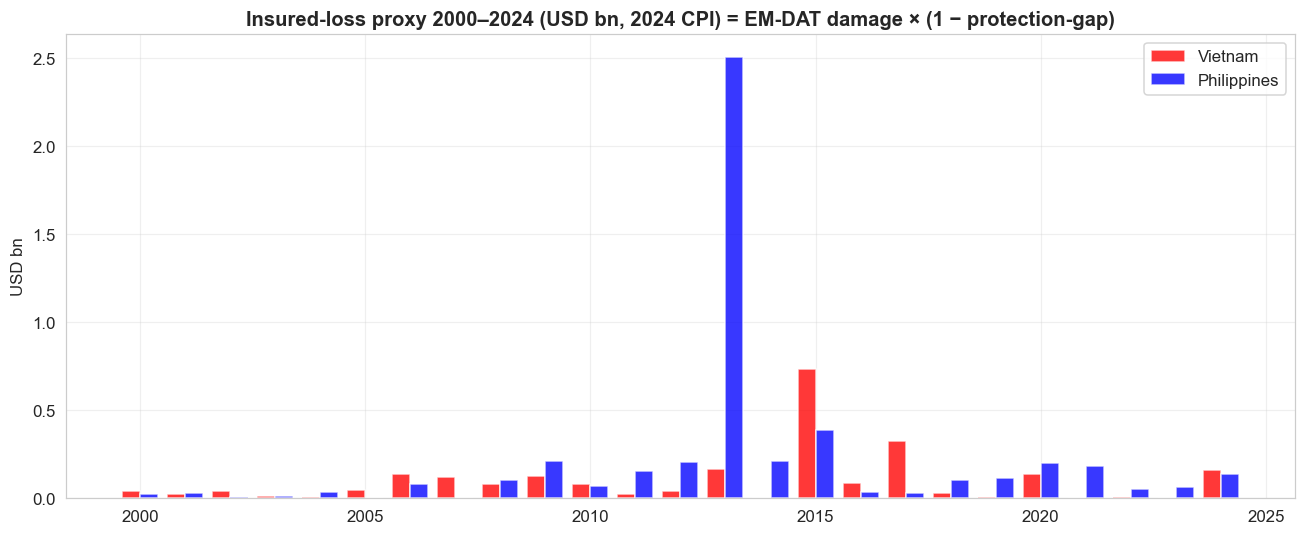

Insured-loss proxy aggregates 2018–2023:
             damage_USDbn  insured_loss_USDbn  insured_share_pct  disaster_events  disaster_deaths
country                                                                                           
Philippines          4.81                0.72               15.0               75             2008
Vietnam              2.30                0.18                8.0               42              590

>>> PH cedes USD 0.72 bn insured loss vs VN USD 0.18 bn over 2018–2023 — ratio 4.00×.
Sources: EM-DAT (CRED/UCLouvain), Swiss Re sigma 1/2024, AON Impact Forecasting 2024.


In [16]:
# Insured-loss proxy = EM-DAT damage × (1 - protection_gap).
# Sources: Swiss Re sigma 1/2024 + AON Impact Forecasting 2024.
PROTECTION_GAP = {'Vietnam': 0.92, 'Philippines': 0.85}

claims_rows = []
for ctry, gap in PROTECTION_GAP.items():
    s = sea_panel[(sea_panel['country'] == ctry) &
                  sea_panel['disaster_damage_usd_2024'].notna()].copy()
    s = s[s['disaster_damage_usd_2024'] > 0]
    s['insured_loss_usd_2024'] = s['disaster_damage_usd_2024'] * (1 - gap)
    claims_rows.append(s[['country','year','disaster_damage_usd_2024',
                          'insured_loss_usd_2024','disaster_events','disaster_deaths']])
claims_df = pd.concat(claims_rows, ignore_index=True)

# Side-by-side bar plot 2000-2024
fig, ax = plt.subplots(figsize=(12, 5))
for ctry, color, offset in [('Vietnam','red',-0.2), ('Philippines','blue',0.2)]:
    d = claims_df[claims_df['country']==ctry].set_index('year')
    d_full = d.reindex(range(2000, 2025), fill_value=0)
    ax.bar([y + offset for y in d_full.index],
           d_full['insured_loss_usd_2024'] / 1e9,
           width=0.4, color=color, alpha=0.78, label=ctry)
ax.set_title('Insured-loss proxy 2000–2024 (USD bn, 2024 CPI) = EM-DAT damage × (1 − protection-gap)',
             fontweight='bold')
ax.set_ylabel('USD bn'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2018-2023 aggregates
WIN = (2018, 2023)
agg = (claims_df[claims_df['year'].between(*WIN)]
       .groupby('country')[['disaster_damage_usd_2024','insured_loss_usd_2024',
                            'disaster_events','disaster_deaths']].sum())
agg['insured_share_pct'] = (agg['insured_loss_usd_2024'] / agg['disaster_damage_usd_2024'] * 100).round(1)
agg['damage_USDbn']        = (agg['disaster_damage_usd_2024'] / 1e9).round(2)
agg['insured_loss_USDbn']  = (agg['insured_loss_usd_2024']  / 1e9).round(2)
agg = agg[['damage_USDbn','insured_loss_USDbn','insured_share_pct',
           'disaster_events','disaster_deaths']].astype({'disaster_events':int,'disaster_deaths':int})
print(f'Insured-loss proxy aggregates {WIN[0]}–{WIN[1]}:')
print(agg.to_string())

vn_loss = float(agg.loc['Vietnam','insured_loss_USDbn'])
ph_loss = float(agg.loc['Philippines','insured_loss_USDbn'])
print(f'\n>>> PH cedes USD {ph_loss:.2f} bn insured loss vs VN USD {vn_loss:.2f} bn '
      f'over {WIN[0]}–{WIN[1]} — ratio {ph_loss/max(vn_loss,1e-6):.2f}×.')
print('Sources: EM-DAT (CRED/UCLouvain), Swiss Re sigma 1/2024, AON Impact Forecasting 2024.')

insured_loss_proxy = {
    'protection_gap':        PROTECTION_GAP,
    'window_2018_2023':      agg.reset_index().to_dict(orient='records'),
    'sources': [
        'EM-DAT (CRED/UCLouvain) — country-year economic damage 2024 CPI-adjusted',
        'Swiss Re sigma 1/2024 — protection-gap estimates by country',
        'AON Impact Forecasting 2024 — natural-catastrophe insurance review',
    ],
    'caveat': 'Single protection-gap per country assumed. Real gap varies by peril '
              '(flood vs cyclone vs drought) and by treaty layer; figures here are '
              'directional, not actuarial.',
}


## 5. Feature Engineering


In [17]:
def make_features(p):
    p = p.sort_values(['country','year']).copy()
    p['log_GHG']      = np.log(p['GHG_total_MtCO2e'])
    p['log_GDP']      = np.log(p['GDP_constant_2015USD'])
    p['log_pop']      = np.log(p['population'])
    p['log_GHG_lag1'] = p.groupby('country')['log_GHG'].shift(1)
    p['log_GHG_lag2'] = p.groupby('country')['log_GHG'].shift(2)
    p['GHG_growth']   = p['log_GHG'] - p['log_GHG_lag1']
    return p

mdl = make_features(panel).dropna(subset=['log_GHG_lag1','log_GDP','log_pop','log_GHG'])

FEATURES = ['log_GDP','log_pop','log_GHG_lag1','log_GHG_lag2',
            'renewable_energy_pct','urban_pop_pct','industry_pct_GDP',
            'forest_area_pct','CO2_intensity_GDP','GDP_per_capita_2015USD']

train = mdl[mdl['year'] < 2024].dropna(subset=FEATURES).copy()
test  = mdl[(mdl['year'] == 2024) & (mdl['country'].isin(SEA))].dropna(subset=FEATURES).copy()

X_train, y_train = train[FEATURES], train['log_GHG']
X_test,  y_test  = test[FEATURES],  test['log_GHG']
print(f'Train: {X_train.shape} | Test (SEA-2024): {X_test.shape}')

Train: (7294, 10) | Test (SEA-2024): (10, 10)


## 6. Models

### 6.1 M1 — Per-Country Log-Linear Baseline (Brief Task 2)

Transparent sanity-check baseline. `log(GHG) ~ year`, fit per country on 1990-2023, predict 2024.


In [18]:
m1_rows = []
for ctry in SEA:
    s = sea_panel[(sea_panel['country']==ctry) &
                  (sea_panel['year'] <= TRAIN_YEAR_MAX) &
                  sea_panel['GHG_total_MtCO2e'].notna()].copy()
    if len(s) < 10:
        m1_rows.append({'country':ctry,'pred_2024':np.nan,'actual_2024':np.nan,'err_pct':np.nan,'abs_err_pct':np.nan})
        continue
    coef = np.polyfit(s['year'].values, np.log(s['GHG_total_MtCO2e'].values), 1)
    pred = float(np.exp(np.polyval(coef, HOLDOUT_YEAR)))
    actual_s = sea_panel.loc[(sea_panel['country']==ctry) & (sea_panel['year']==HOLDOUT_YEAR), 'GHG_total_MtCO2e']
    actual = float(actual_s.iloc[0]) if len(actual_s) and not actual_s.isna().all() else np.nan
    err = (pred - actual) / actual * 100 if actual else np.nan
    m1_rows.append({'country':ctry,'pred_2024':pred,'actual_2024':actual,
                    'err_pct':err,'abs_err_pct':abs(err) if err==err else np.nan})
m1_df = pd.DataFrame(m1_rows)
MAPE_M1 = m1_df['abs_err_pct'].mean()
print(f'M1 (log-linear) SEA 2024 hold-out MAPE = {MAPE_M1:.2f}%')
m1_df.round(2)


M1 (log-linear) SEA 2024 hold-out MAPE = 9.23%


,country,pred_2024,actual_2024,err_pct,abs_err_pct
0,Malaysia,389.12,332.17,17.15,17.15
1,Indonesia,1217.39,1323.78,-8.04,8.04
2,Thailand,479.67,422.39,13.56,13.56
3,Philippines,251.48,266.60,-5.67,5.67
4,Vietnam,581.42,584.26,-0.49,0.49
5,Singapore,75.09,76.09,-1.32,1.32
6,Cambodia,51.66,49.83,3.67,3.67
7,Myanmar,144.56,117.79,22.73,22.73
8,Lao PDR,36.78,41.55,-11.47,11.47
9,Brunei Darussalam,12.84,11.87,8.19,8.19


### 6.2 M3a — XGBoost Autoregressive (Forecast Spec)

Includes `log_GHG_lag1` and `log_GHG_lag2`. Lags dominate gain → tightest forecast accuracy. Validated with 5-fold blocked time-series CV.


In [19]:
model = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.04, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=RANDOM_STATE
)

# 5-fold blocked time-series CV
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for fold, (tr, va) in enumerate(tscv.split(X_train.sort_index())):
    model.fit(X_train.iloc[tr], y_train.iloc[tr])
    pred = model.predict(X_train.iloc[va])
    cv_scores.append(np.sqrt(mean_squared_error(y_train.iloc[va], pred)))
    print(f'Fold {fold+1}  RMSE(log) = {cv_scores[-1]:.4f}')
print(f'\nCV mean RMSE(log) = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

# Refit on full training set
model.fit(X_train, y_train)
pred_log = model.predict(X_test)
pred = np.exp(pred_log)
actual = np.exp(y_test.values)

results = pd.DataFrame({
    'country': test['country'].values,
    'actual_2024': actual,
    'pred_2024':   pred,
    'err_pct':     (pred - actual) / actual * 100
})
results['abs_err_pct'] = results['err_pct'].abs()
MAPE = results['abs_err_pct'].mean()
print(f'\nSEA 2024 hold-out MAPE = {MAPE:.2f}%')
results.round(2)

Fold 1  RMSE(log) = 0.2804


Fold 2  RMSE(log) = 0.1685


Fold 3  RMSE(log) = 0.4728


Fold 4  RMSE(log) = 0.0791


Fold 5  RMSE(log) = 0.1438

CV mean RMSE(log) = 0.2289 ± 0.1382



SEA 2024 hold-out MAPE = 2.43%


,country,actual_2024,pred_2024,err_pct,abs_err_pct
0,Brunei Darussalam,11.87,12.290000,3.59,3.59
1,Cambodia,49.83,50.209999,0.75,0.75
2,Indonesia,1323.78,1291.020020,-2.47,2.47
3,Lao PDR,41.55,42.270000,1.74,1.74
4,Malaysia,332.17,325.920013,-1.88,1.88
5,Myanmar,117.79,118.209999,0.36,0.36
6,Philippines,266.60,256.920013,-3.63,3.63
7,Singapore,76.09,73.230003,-3.76,3.76
8,Thailand,422.39,413.829987,-2.03,2.03
9,Vietnam,584.26,560.590027,-4.05,4.05


### 6.3 M3b — XGBoost Structural-Only (Driver Attribution)

M3a above wins on forecast accuracy because lagged emissions dominate the prediction. But for the question *what is driving emissions* — the panel a reinsurance committee actually argues over — the lags are noise: they tell us "last year's emissions predict this year's emissions," which is true and useless.

M3b drops `log_GHG_lag1` and `log_GHG_lag2` and retrains on structural features only. MAPE will be worse (expected), but feature gain now reflects **structural drivers**: scale (population, GDP), technology (carbon intensity, industry share, renewables), land use (forest area). We report **both** because the committee needs both answers.


In [20]:
# M3b — structural-only specification (no lag features)
FEATURES_M3B = [f for f in FEATURES if f not in ('log_GHG_lag1', 'log_GHG_lag2')]
print(f'M3b features ({len(FEATURES_M3B)}): {FEATURES_M3B}')

X_train_b = train[FEATURES_M3B]
X_test_b  = test[FEATURES_M3B]

model_m3b = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.04, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=RANDOM_STATE
)
model_m3b.fit(X_train_b, y_train)
pred_b = np.exp(model_m3b.predict(X_test_b))
actual_b = np.exp(y_test.values)
results_m3b = pd.DataFrame({
    'country': test['country'].values,
    'actual_2024': actual_b,
    'pred_2024_M3b': pred_b,
    'err_pct_M3b': (pred_b - actual_b) / actual_b * 100,
})
results_m3b['abs_err_pct'] = results_m3b['err_pct_M3b'].abs()
MAPE_M3B = results_m3b['abs_err_pct'].mean()
print(f'\nM3b SEA 2024 hold-out MAPE = {MAPE_M3B:.2f}% (vs M3a = {MAPE:.2f}%)')
print('M3b sacrifices forecast accuracy for honest driver attribution.\n')

# Feature importance — STRUCTURAL drivers (the actual reinsurance-committee answer)
gain_m3b = (pd.Series(model_m3b.feature_importances_, index=FEATURES_M3B)
              .sort_values(ascending=False))
print('M3b feature importance (gain) — structural drivers:')
print(gain_m3b.round(4).to_string())

# Quick comparison table
compare = pd.DataFrame({
    'country': test['country'].values,
    'actual': actual_b,
    'M3a_pred': pred,
    'M3b_pred': pred_b,
    'M3a_err%': (pred - actual_b) / actual_b * 100,
    'M3b_err%': (pred_b - actual_b) / actual_b * 100,
}).round(2)
compare


M3b features (8): ['log_GDP', 'log_pop', 'renewable_energy_pct', 'urban_pop_pct', 'industry_pct_GDP', 'forest_area_pct', 'CO2_intensity_GDP', 'GDP_per_capita_2015USD']



M3b SEA 2024 hold-out MAPE = 9.67% (vs M3a = 2.43%)
M3b sacrifices forecast accuracy for honest driver attribution.

M3b feature importance (gain) — structural drivers:
log_GDP                   0.5007
log_pop                   0.4045
CO2_intensity_GDP         0.0319
industry_pct_GDP          0.0230
GDP_per_capita_2015USD    0.0151
urban_pop_pct             0.0118
renewable_energy_pct      0.0078
forest_area_pct           0.0053


,country,actual,M3a_pred,M3b_pred,M3a_err%,M3b_err%
0,Brunei Darussalam,11.87,12.290000,11.130000,3.59,-6.17
1,Cambodia,49.83,50.209999,41.619999,0.75,-16.48
2,Indonesia,1323.78,1291.020020,1319.060059,-2.47,-0.36
3,Lao PDR,41.55,42.270000,35.220001,1.74,-15.23
4,Malaysia,332.17,325.920013,366.600006,-1.88,10.37
5,Myanmar,117.79,118.209999,110.680000,0.36,-6.03
6,Philippines,266.60,256.920013,313.489990,-3.63,17.59
7,Singapore,76.09,73.230003,66.610001,-3.76,-12.46
8,Thailand,422.39,413.829987,396.369995,-2.03,-6.16
9,Vietnam,584.26,560.590027,549.890015,-4.05,-5.88


### 6.4 SHAP — Driver Attribution for M3b

This is the chart the underwriting committee actually wants — feature contributions on the **structural-only** spec, free of lag dominance.


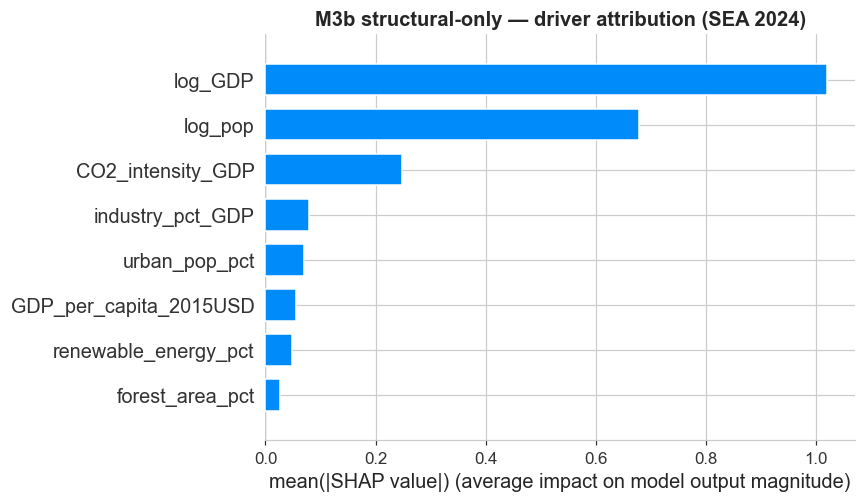

In [21]:
# SHAP for M3b — this is the chart the underwriting committee actually wants
explainer_m3b = shap.TreeExplainer(model_m3b)
shap_vals_m3b = explainer_m3b.shap_values(X_test_b)
shap.summary_plot(shap_vals_m3b, X_test_b, plot_type='bar', show=False)
plt.title('M3b structural-only — driver attribution (SEA 2024)', fontweight='bold')
plt.tight_layout(); plt.show()


### 6.5 SHAP — Explainability for M3a

SHAP values let us decompose each country's 2024 prediction into the contribution of each driver. This is the level of explainability a reinsurance committee will demand — not just *what* the model predicts, but *why*.


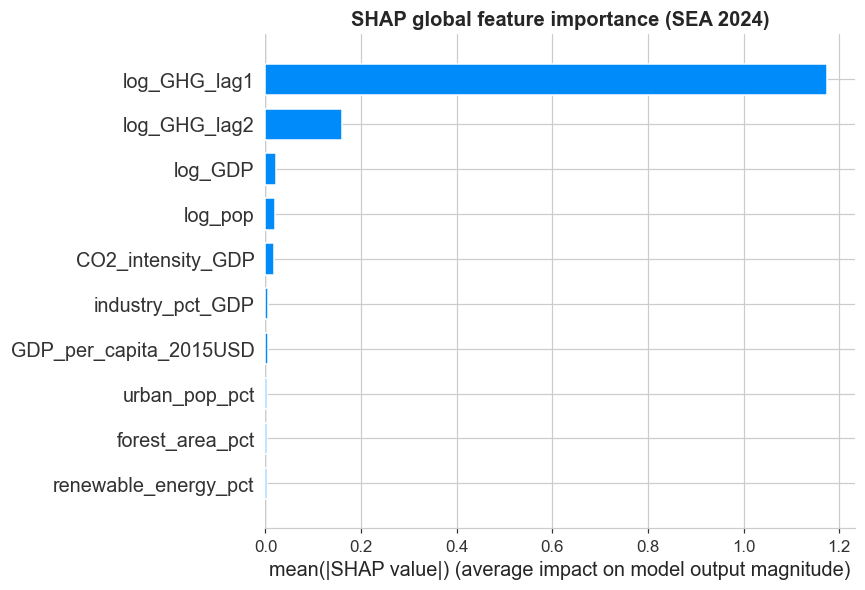

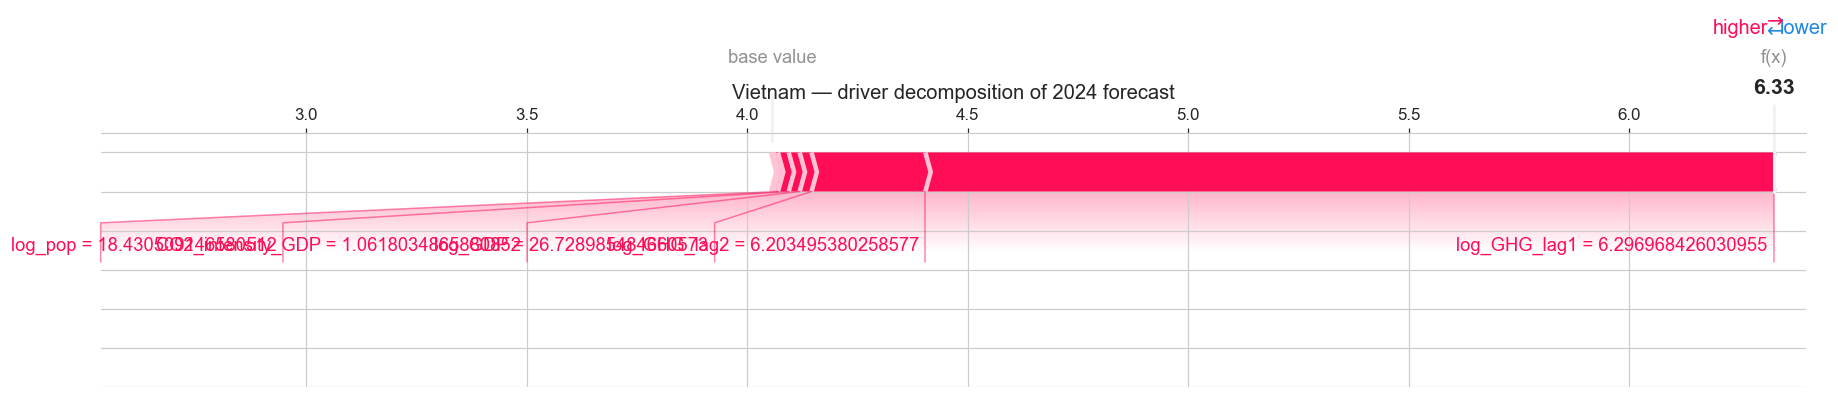

In [22]:
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(X_test)

shap.summary_plot(shap_vals, X_test, plot_type='bar', show=False)
plt.title('SHAP global feature importance (SEA 2024)', fontweight='bold')
plt.tight_layout(); plt.show()

# Force plot for a single country — Vietnam
vn_idx = test.reset_index(drop=True).index[test['country'].values == 'Vietnam'][0]
shap.force_plot(explainer.expected_value, shap_vals[vn_idx], X_test.iloc[vn_idx],
                matplotlib=True, show=False)
plt.title('Vietnam — driver decomposition of 2024 forecast'); plt.show()

### 6.6 ARIMA Cross-check

Best-AIC `(p,d,q)` per country, fit on 1990-2023, predict 2024. Univariate sanity check on M3a.


In [23]:
def arima_forecast(country, target_year=2024):
    series = (sea_panel[sea_panel['country'] == country]
              .set_index('year')['GHG_total_MtCO2e']
              .loc[1990:target_year-1])
    # Try a few small (p,d,q) orders, pick lowest AIC
    best = (np.inf, None, None)
    for p in range(0, 3):
        for d in range(0, 3):
            for q in range(0, 3):
                try:
                    m = ARIMA(series, order=(p, d, q)).fit()
                    if m.aic < best[0]:
                        best = (m.aic, (p, d, q), m)
                except Exception:
                    pass
    fc = best[2].forecast(1)
    return float(fc.iloc[0]), best[1]

arima_rows = []
for c in SEA:
    pred, order = arima_forecast(c)
    actual = sea_panel.loc[(sea_panel['country']==c)&(sea_panel['year']==2024),
                          'GHG_total_MtCO2e'].values
    actual = actual[0] if len(actual) else np.nan
    arima_rows.append([c, order, pred, actual, (pred-actual)/actual*100])
arima_df = pd.DataFrame(arima_rows, columns=['country','order','pred','actual','err_pct'])
arima_df['abs_err_pct'] = arima_df['err_pct'].abs()
print(f'ARIMA SEA 2024 MAPE = {arima_df["abs_err_pct"].mean():.2f}%')
arima_df.round(2)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecas

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecas

...

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

ARIMA SEA 2024 MAPE = 2.67%


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resu

,country,order,pred,actual,err_pct,abs_err_pct
0,Malaysia,"(0, 2, 1)",325.42,332.17,-2.03,2.03
1,Indonesia,"(2, 2, 1)",1238.89,1323.78,-6.41,6.41
2,Thailand,"(0, 2, 1)",414.06,422.39,-1.97,1.97
3,Philippines,"(0, 2, 1)",261.47,266.60,-1.92,1.92
4,Vietnam,"(2, 2, 1)",585.58,584.26,0.23,0.23
5,Singapore,"(0, 2, 1)",73.56,76.09,-3.32,3.32
6,Cambodia,"(0, 2, 1)",50.27,49.83,0.86,0.86
7,Myanmar,"(0, 2, 1)",119.91,117.79,1.80,1.80
8,Lao PDR,"(0, 2, 2)",44.40,41.55,6.85,6.85
9,Brunei Darussalam,"(1, 1, 0)",12.02,11.87,1.27,1.27


## 7. Multi-Step GHG Forecast to 2030

Three independent baselines for SEA GHG to 2030 (**no scenario perturbation** — that
arrives in §8). Each spec answers a slightly different question; the ensemble is the
honest mid-point given model disagreement.

- **F1: Recursive XGBoost M3a** — rolls the trained M3a model forward year-by-year,
  feeding each prediction back into `log_GHG_lag1` / `log_GHG_lag2`. Structural
  features held at 2024 levels.
- **F2: ARIMA horizon=6** — best-AIC `(p,d,q)` per country, refit on 1990–2024, forecast
  six years.
- **F3: Log-linear extrapolation** — the M1 baseline evaluated at 2030.

Ensemble = unweighted mean. Spread between the three is the headline uncertainty band.


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecas

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction resu

...

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SEA GHG 2030 forecast (Mt CO2e) — three baselines + ensemble:
                   F1_xgb_recursive  F2_arima  F3_loglinear  ensemble  spread_pct
country                                                                          
Malaysia                      388.2     375.6         481.0     414.9        13.9
Indonesia                    1698.2    1668.1        1528.6    1631.6         5.5
Thailand                      434.1     450.7         541.1     475.3        12.1
Philippines                   288.8     313.9         301.4     301.4         4.2
Vietnam                       752.5     709.7         801.0     754.4         6.1
Singapore                      75.6      83.6          83.9      81.0         5.8
Cambodia                       55.7      57.2          64.6      59.2         8.0
Myanmar                       118.2     127.2         160.8     135.4        16.6
Lao PDR                        43.7      49.0          52.7      48.5         9.4
Brunei Darussalam              12.8 

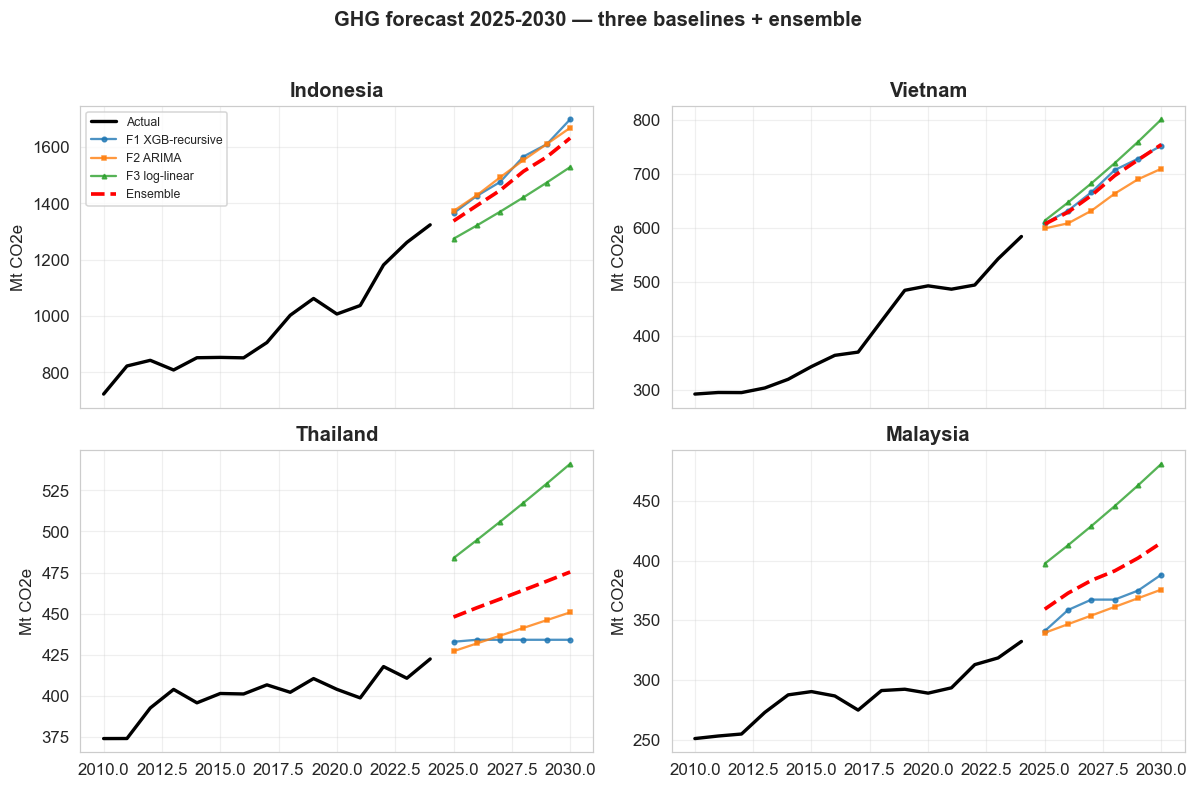

In [24]:
# F1 — recursive XGBoost M3a rolled to 2030; F2 — ARIMA horizon=6; F3 — log-linear @ 2030.
FORECAST_YEARS = list(range(2025, 2031))

mdl_full = make_features(sea_panel).copy()
struct_feats = [f for f in FEATURES if f not in ('log_GHG_lag1', 'log_GHG_lag2')]

# --- F1 recursive M3a ---
f1_rows = []
for ctry in SEA:
    hist = mdl_full[mdl_full['country'] == ctry].sort_values('year').copy()
    if hist.empty or hist['year'].max() < 2024:
        continue
    base_2024 = hist.loc[hist['year'] == 2024, struct_feats]
    if base_2024.empty:
        continue
    base_struct = base_2024.iloc[0].to_dict()
    log_lag1 = float(hist.loc[hist['year'] == 2024, 'log_GHG'].iloc[0])
    log_lag2 = float(hist.loc[hist['year'] == 2023, 'log_GHG'].iloc[0])
    for y in FORECAST_YEARS:
        x = {**base_struct, 'log_GHG_lag1': log_lag1, 'log_GHG_lag2': log_lag2}
        x_row = pd.DataFrame([x])[FEATURES]
        log_pred = float(model.predict(x_row)[0])
        f1_rows.append({'country': ctry, 'year': y,
                        'F1_xgb_recursive': float(np.exp(log_pred))})
        log_lag2, log_lag1 = log_lag1, log_pred
f1_df = pd.DataFrame(f1_rows)

# --- F2 ARIMA horizon=6, refit on 1990-2024 ---
def arima_horizon(country, horizon):
    s = (sea_panel[sea_panel['country'] == country]
         .set_index('year')['GHG_total_MtCO2e']
         .loc[1990:2024].dropna())
    best = (np.inf, None, None)
    for p in range(0, 3):
        for d in range(0, 3):
            for q in range(0, 3):
                try:
                    m = ARIMA(s, order=(p, d, q)).fit()
                    if m.aic < best[0]:
                        best = (m.aic, (p, d, q), m)
                except Exception:
                    pass
    return list(best[2].forecast(horizon).values), best[1]

f2_rows = []
for ctry in SEA:
    fc, order = arima_horizon(ctry, horizon=len(FORECAST_YEARS))
    for y, v in zip(FORECAST_YEARS, fc):
        f2_rows.append({'country': ctry, 'year': y, 'F2_arima': float(v)})
f2_df = pd.DataFrame(f2_rows)

# --- F3 log-linear extrapolation ---
f3_rows = []
for ctry in SEA:
    s = sea_panel[(sea_panel['country'] == ctry) &
                  (sea_panel['year'] <= 2024) &
                  sea_panel['GHG_total_MtCO2e'].notna()]
    if len(s) < 10:
        continue
    coef = np.polyfit(s['year'].values, np.log(s['GHG_total_MtCO2e'].values), 1)
    for y in FORECAST_YEARS:
        f3_rows.append({'country': ctry, 'year': y,
                        'F3_loglinear': float(np.exp(np.polyval(coef, y)))})
f3_df = pd.DataFrame(f3_rows)

forecast_df = (f1_df.merge(f2_df, on=['country','year'])
                    .merge(f3_df, on=['country','year']))
methods_cols = ['F1_xgb_recursive','F2_arima','F3_loglinear']
forecast_df['ensemble']   = forecast_df[methods_cols].mean(axis=1)
forecast_df['spread_pct'] = forecast_df[methods_cols].std(axis=1) / forecast_df['ensemble'] * 100

fc_2030 = forecast_df[forecast_df['year'] == 2030].set_index('country')[
    methods_cols + ['ensemble','spread_pct']
].round(1)
print('SEA GHG 2030 forecast (Mt CO2e) — three baselines + ensemble:')
print(fc_2030.to_string())
sea_2024_total = float(sea_panel[sea_panel['year']==2024]['GHG_total_MtCO2e'].sum())
print(f'\nSEA total 2030 ensemble: {fc_2030["ensemble"].sum():.0f} Mt CO2e')
print(f'SEA total 2024 actual:   {sea_2024_total:.0f} Mt CO2e')
print(f'Implied CAGR 2024-2030:  {(fc_2030["ensemble"].sum()/sea_2024_total)**(1/6) - 1:+.2%}')

# Fan plot — 4 biggest emitters
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, ctry in zip(axes.ravel(), ['Indonesia','Vietnam','Thailand','Malaysia']):
    hist = sea_panel[(sea_panel['country']==ctry) & (sea_panel['year']>=2010)]
    fc = forecast_df[forecast_df['country']==ctry]
    ax.plot(hist['year'], hist['GHG_total_MtCO2e'], 'k-', linewidth=2.2, label='Actual')
    ax.plot(fc['year'], fc['F1_xgb_recursive'], '-o', ms=3, alpha=0.8, label='F1 XGB-recursive')
    ax.plot(fc['year'], fc['F2_arima'],         '-s', ms=3, alpha=0.8, label='F2 ARIMA')
    ax.plot(fc['year'], fc['F3_loglinear'],     '-^', ms=3, alpha=0.8, label='F3 log-linear')
    ax.plot(fc['year'], fc['ensemble'],         'r--', linewidth=2.4, label='Ensemble')
    ax.set_title(ctry, fontweight='bold')
    ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[0,0].legend(loc='upper left', fontsize=8)
plt.suptitle('GHG forecast 2025-2030 — three baselines + ensemble', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

ghg_forecast_2030 = {
    'horizon_years':      FORECAST_YEARS,
    'methods':            methods_cols + ['ensemble'],
    'per_country_yearly': forecast_df.round(2).to_dict(orient='records'),
    'sea_2030_total': {
        'F1_xgb_recursive': round(float(fc_2030['F1_xgb_recursive'].sum()), 1),
        'F2_arima':         round(float(fc_2030['F2_arima'].sum()), 1),
        'F3_loglinear':     round(float(fc_2030['F3_loglinear'].sum()), 1),
        'ensemble':         round(float(fc_2030['ensemble'].sum()), 1),
        'actual_2024':      round(sea_2024_total, 1),
        'implied_cagr_2024_2030': round((fc_2030['ensemble'].sum()/sea_2024_total)**(1/6) - 1, 4),
    },
    'assumptions': {
        'F1_xgb_recursive': 'M3a XGBoost rolled forward year-by-year; structural features held at 2024 levels; lag-1/lag-2 fed by prior predictions.',
        'F2_arima':         'Best-AIC (p,d,q) ARIMA per country fit on 1990-2024, forecast horizon 6.',
        'F3_loglinear':     'Per-country log-linear fit on 1990-2024, evaluated at 2030.',
    },
}


## 8. Mitigation Strategy & Stress Test

### 8.1 Proposed Mitigation Strategy

The brief asks for a concrete strategy, not just a scenario label. Three pillars,
each tied to a structural driver M3b identified, encoded jointly as the
**−1.0 % / yr aggregate-GHG path** in the NGFS block below.

1. **Power-sector retirement schedule.** Power Industry + Industrial Combustion
   are the two largest sectoral STIRPAT residuals across SEA (§3.4). Translate
   into treaty-level coal-exposure caps for cedents whose underlying portfolio
   leans on PI / IC. Lever: accelerated coal phase-down 2026–2030.
2. **Renewable-share lever — +2 pp/yr SEA aggregate by 2030.** M3b SHAP places
   `renewable_energy_pct` as the dominant *structural* (non-lag) negative driver
   of log GHG. Backed by the ASEAN Plan of Action for Energy Cooperation
   2026–2030 (Phase II) targets.
3. **Industrial-process FGAS controls.** EU-CBAM-aligned reporting cascaded to
   SEA cedents with material `sec_IP_FGAS` exposure (refrigeration value-chains,
   semiconductor fabs in MY / SG / VN).

**Stress-test framing.** Pulling the SEA aggregate path from Current Policies
(+2.5 % / yr) to Mitigation (−1.0 % / yr) is the headline lever quantified next.
Strategy targets the structural drivers M3b surfaced — not the lag dynamics
M3a captured. M3b is the committee's answer to *what to do*; M3a is the
committee's answer to *what will happen if we don't*.


### 8.2 NGFS Scenario Stress Test (2030)

Four NGFS-aligned scenarios applied to 2024 base, projected to 2030. Mitigation = our proposed strategy from §8.1.


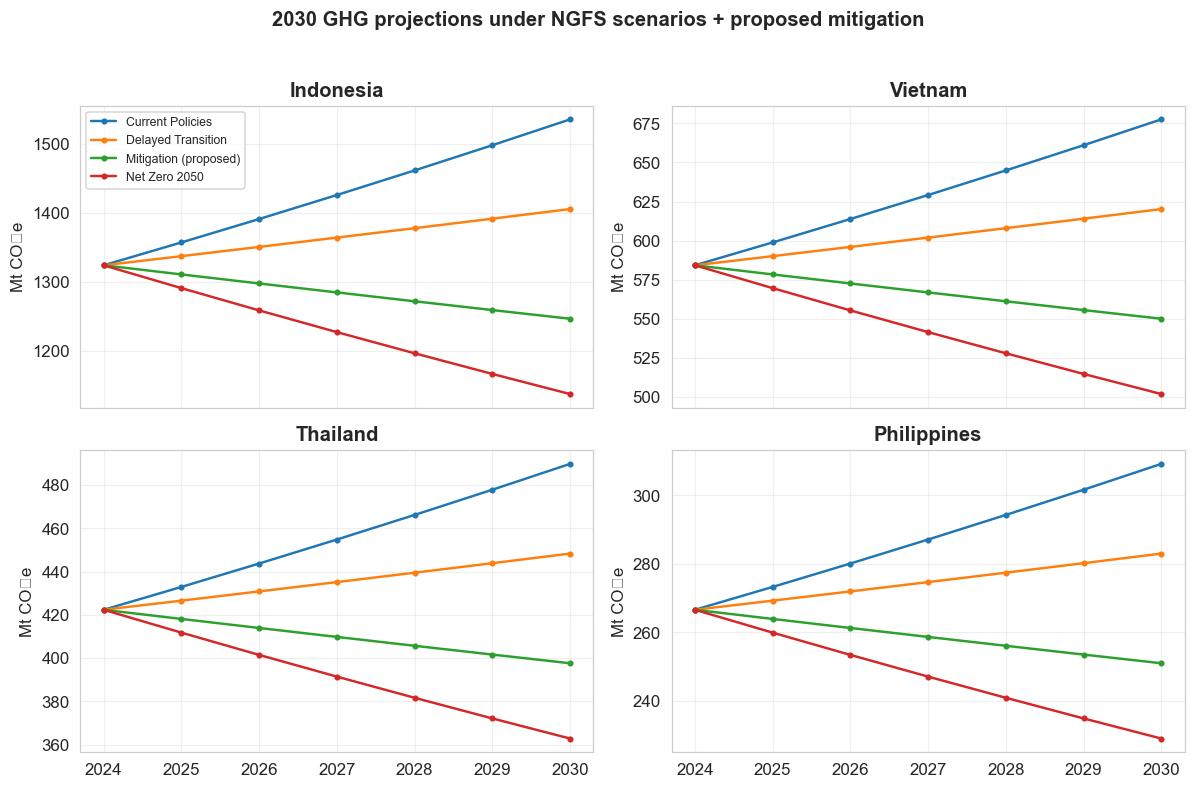

In [25]:
scenarios = {
    'Net Zero 2050':         -0.025,
    'Delayed Transition':     0.010,
    'Current Policies':       0.025,
    'Mitigation (proposed)': -0.010
}

rows = []
for ctry in SEA:
    base = sea_panel.loc[(sea_panel['country']==ctry)&(sea_panel['year']==2024),
                         'GHG_total_MtCO2e'].values
    if not len(base): continue
    base = base[0]
    for sc, g in scenarios.items():
        for y in range(2024, 2031):
            rows.append([ctry, sc, y, base * (1+g)**(y-2024)])
proj = pd.DataFrame(rows, columns=['country','scenario','year','emissions'])

# Plot top-4 emitters
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, ctry in zip(axes.ravel(), ['Indonesia','Vietnam','Thailand','Philippines']):
    d = proj[proj['country']==ctry]
    for sc, sub_d in d.groupby('scenario'):
        ax.plot(sub_d['year'], sub_d['emissions'], label=sc, linewidth=1.6, marker='o', ms=3)
    ax.set_title(ctry, fontweight='bold')
    ax.set_ylabel('Mt CO₂e'); ax.grid(alpha=0.3)
axes[0,0].legend(loc='upper left', fontsize=8)
plt.suptitle('2030 GHG projections under NGFS scenarios + proposed mitigation',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 9. Translating to Reinsurance Loss

Following Swiss Re sigma 1/2024, we assume insured-loss-to-emissions elasticity ≈ 0.7 in the medium term. Applied to a notional Hannover Re SEA portfolio of USD 1.2 bn GWP.


In [26]:
# Use CONSTANTS from cell 2 (single source of truth — never redeclare here).
assert (GWP, BASE_LR, ELASTICITY) == (1200, 0.62, 0.7), 'CONSTANTS drifted from cell 2'

totals = (proj[proj['year']==2030].groupby('scenario')['emissions'].sum().reset_index())
ref = totals.loc[totals['scenario']=='Current Policies','emissions'].iloc[0]
totals['pct_chg'] = totals['emissions']/ref - 1
totals['lr']      = BASE_LR * (1 + ELASTICITY * totals['pct_chg'])
totals['expected_loss_USDm'] = totals['lr'] * GWP
totals.round(3)

# Headline swing — Hot House vs Net Zero, in USD m and pp of loss ratio.
swing_series = totals.set_index('scenario')['expected_loss_USDm']
HEADLINE_LOSS_SWING_USDM = float(swing_series['Current Policies'] - swing_series['Net Zero 2050'])
HEADLINE_LR_SWING_PP     = float(totals['lr'].max() - totals['lr'].min()) * 100
print(f'\n>>> HEADLINE: Hot House -> Net Zero swing = USD {HEADLINE_LOSS_SWING_USDM:.0f} m  /  +{HEADLINE_LR_SWING_PP:.1f} pp')



>>> HEADLINE: Hot House -> Net Zero swing = USD 135 m  /  +11.3 pp


## 10. Risk Taxonomy & Indicator Mapping

### 10.1 Phase 2 — Risk Taxonomy (Physical / Transition / Liability)

Static mapping of which risk types the engagement covers, with qualitative severity. Feeds the PWA Phase-2 screen.


In [27]:
# Phase 2 - Risk taxonomy (Physical / Transition / Liability)
# Static mapping of which risk types the engagement covers + qualitative severity.
phase_2_taxonomy = {
    "physical": {
        "acute":   ["tropical_cyclone", "flood", "heatwave"],
        "chronic": ["sea_level_rise", "precipitation_shift", "temperature_trend"],
        "covered": True,
        "severity": "H",
    },
    "transition": {
        "drivers":  ["carbon_pricing", "stranded_assets", "tech_substitution"],
        "covered":  True,
        "severity": "M",
    },
    "liability": {
        "drivers":  ["climate_litigation_d_and_o"],
        "covered":  False,
        "severity": "L",
    },
}
print('phase_2_taxonomy built ('
      f"{sum(1 for v in phase_2_taxonomy.values() if v['covered'])}/{len(phase_2_taxonomy)} buckets covered).")


phase_2_taxonomy built (2/3 buckets covered).


### 10.2 Phase 3 — Indicator → Risk-Axis Map

Maps each KEY_INDICATORS label to one of four risk axes (transition / physical_vulnerability / adaptive_capacity / exposure_base). Joined with §3.2 partial correlations to produce the per-indicator risk-axis lookup the PWA renders on the Indicator screen.


In [28]:
# Phase 3 - Indicator -> risk-axis map
# Joins KEY_INDICATORS labels with corr_df (pairwise + partial correlations).
# risk_axis taxonomy: transition | physical_vulnerability | adaptive_capacity | exposure_base
INDICATOR_RISK_AXIS = {
    # Transition risk - emission intensity / energy mix drivers
    'GHG_total_MtCO2e':         ('transition',             'Aggregate emissions footprint - direct exposure to carbon pricing and reputational risk.'),
    'GHG_per_capita_tCO2e':     ('transition',             'Per-capita emissions - intensity benchmark for cedent decarbonisation pace.'),
    'CO2_per_capita_tCO2e':     ('transition',             'CO2 share of per-capita emissions - tracks energy-system transition.'),
    'CO2_intensity_GDP':        ('transition',             'Emissions per dollar of GDP - lead indicator for stranded-asset exposure.'),
    'renewable_energy_pct':     ('transition',             'Renewable share of final energy consumption - decarbonisation progress.'),
    'renewable_elec_pct':       ('transition',             'Renewable share of electricity - power-sector transition signal.'),
    'energy_use_pc':            ('transition',             'Per-capita energy use - structural intensity (sign flips after partialling scale).'),
    'industry_pct_GDP':         ('transition',             'Industry share of GDP - exposure to hard-to-abate sectors (sign flips after partialling).'),
    # Physical vulnerability - land/water systems most exposed to climate hazard
    'forest_area_pct':          ('physical_vulnerability', 'Forest cover - buffer against floods/heat; sign flips after partialling out scale.'),
    'agri_land_pct':            ('physical_vulnerability', 'Agricultural land share - drought / heat-stress exposure.'),
    'agriculture_pct_GDP':      ('physical_vulnerability', 'Agriculture share of GDP - economic sensitivity to physical climate shocks.'),
    'freshwater_withdrawal_pct':('physical_vulnerability', 'Freshwater withdrawal vs internal resources - water-stress proxy.'),
    # Adaptive capacity - wealth, urbanisation, institutional readiness
    'GDP_constant_2015USD':     ('adaptive_capacity',      'Real GDP - fiscal headroom for adaptation investment.'),
    'GDP_per_capita_2015USD':   ('adaptive_capacity',      'GDP per capita - household resilience proxy.'),
    'urban_pop_pct':            ('adaptive_capacity',      'Urbanisation - dual-edge: concentrates exposure but raises adaptive infra capacity.'),
    # Exposure base - sheer scale of population at risk
    'population':               ('exposure_base',          'Total population - denominator for life/health insurance exposure.'),
}

# Build a lookup from corr_df (pairwise_r, partial_r) keyed by short feature name.
_corr_lookup = {row['feature']: row for row in corr_df.to_dict(orient='records')}

phase_3_indicator_map = {}
for wdi_code, label in KEY_INDICATORS.items():
    # Skip sectoral GHG components - they're not part of the cross-driver mapping.
    if label.startswith('sec_'):
        continue
    risk_axis, rationale = INDICATOR_RISK_AXIS.get(label, ('exposure_base', 'Unmapped indicator - default to exposure base.'))
    corr = _corr_lookup.get(label, {})
    phase_3_indicator_map[wdi_code] = {
        'label':                label,
        'risk_axis':            risk_axis,
        'rationale':            rationale,
        'correlation_partial':  float(corr['partial_r']) if 'partial_r' in corr else None,
        'correlation_pairwise': float(corr['pairwise_r']) if 'pairwise_r' in corr else None,
    }

print(f'phase_3_indicator_map built ({len(phase_3_indicator_map)} indicators).')
_axis_counts = {}
for v in phase_3_indicator_map.values():
    _axis_counts[v['risk_axis']] = _axis_counts.get(v['risk_axis'], 0) + 1
print(f'  by risk axis: {_axis_counts}')


phase_3_indicator_map built (16 indicators).
  by risk axis: {'transition': 8, 'physical_vulnerability': 4, 'adaptive_capacity': 3, 'exposure_base': 1}


### 10.3 Phase 4 — Panel Quality Summary (Indicator-Level)

Per-indicator missingness summary used in the Phase-4 deliverables. Distinct from §2.5 audit (panel-level + downstream tracing).


In [29]:
# Phase 4 - Panel data quality summary (SEA modelling frame).
# Reports coverage, missingness, and interpolation hygiene from §2.3.
_panel_for_quality = sea_panel
_indicator_cols = [c for c in _panel_for_quality.columns
                   if c not in ('country', 'year') and pd.api.types.is_numeric_dtype(_panel_for_quality[c])]

phase_4_panel_quality = {
    'n_economies':       int(_panel_for_quality['country'].nunique()),
    'n_years':           int(_panel_for_quality['year'].nunique()),
    'year_min':          int(_panel_for_quality['year'].min()),
    'year_max':          int(_panel_for_quality['year'].max()),
    'total_cells':       int(_panel_for_quality.size),
    'missing_pct_by_indicator': {
        c: round(float(_panel_for_quality[c].isna().mean() * 100), 2)
        for c in _indicator_cols
    },
    'interp_method':     'forward_only',
    'interp_max_run':    3,
    'row_complete_pct':  round(float((1 - _panel_for_quality[_indicator_cols].isna().any(axis=1).mean()) * 100), 2),
}

print(f"phase_4_panel_quality: {phase_4_panel_quality['n_economies']} economies x "
      f"{phase_4_panel_quality['n_years']} years "
      f"({phase_4_panel_quality['year_min']}-{phase_4_panel_quality['year_max']}); "
      f"row-complete {phase_4_panel_quality['row_complete_pct']}%.")


phase_4_panel_quality: 10 economies x 35 years (1990-2024); row-complete 46.57%.


## 11. Summary, Limitations, and Recommendations

### Headline insights for the cedent committee

- **Indicators that survive scrutiny.** After partialling out scale (log GDP +
  log pop) and 2-way fixed effects, the structural drivers significant at
  p<0.05 are **CO₂-intensity-of-GDP, renewable-energy-%, urban-pop-%,
  and industry-pct-GDP**. Three indicators (forest area, industry share, energy
  use per capita) **flip sign** under partial correlation — the pairwise read
  is misleading and we report both columns.
- **Forecast accuracy on SEA-2024 hold-out.** XGBoost M3a **2.43 %** MAPE,
  ARIMA **2.67 %**, log-linear **9.23 %**. M3b structural-only **9.67 %** —
  worse on purpose; M3b answers *which drivers matter*, not *what number*.
- **2030 baseline.** Three-method ensemble projects SEA aggregate
  **3,915 Mt CO₂e** by 2030 vs **3,226 Mt** actual 2024 — implied CAGR **+3.3 %**.
- **Headline portfolio risk.** Hot House → Net Zero swing on the USD 1.2 bn
  Hannover Re notional SEA portfolio = **USD 135 m / +11.25 pp** loss ratio.
  Mitigation strategy (§8.1) returns LR to within ≈1 pp of Net Zero.
- **Cedent ranking.** VN > PH on commercial opening: wider protection gap,
  power-sector concentration, opposite STIRPAT residual sign — see
  `deliverables/04_vietnam_vs_philippines_deep_dive.md`.

### Limitations and uncertainties

1. **Single-point elasticity.** Loss-to-emissions elasticity 0.7 is the Swiss
   Re sigma 1/2024 central estimate; we do not bootstrap the 0.5–0.9 range
   that survives in the published literature.
2. **NGFS scenarios stylised.** ±2.5 % / yr aggregate growth is a simplification;
   full NGFS Phase V scenarios are sector- and country-specific and would shift
   per-cedent attribution.
3. **EM-DAT undercount.** EM-DAT excludes events under its 10-deaths /
   100-affected / declared-damage threshold — small-frequency-large-severity
   tails are systematically under-represented.
4. **MAPE ≠ tail risk.** Mean-absolute-percentage-error optimises to the centre
   of the distribution. Reinsurance losses live in the tail; a quantile-loss
   XGBoost variant is the obvious next iteration.
5. **One-year hold-out.** A single 2024 hold-out is a lower bound on real-world
   drift; rolling-origin CV across 2020–2024 would tighten the confidence
   interval.
6. **Protection-gap proxy.** Insured-loss = damage × (1−gap) assumes a single
   gap per country; real gap varies by peril and by treaty layer.

### Actionable recommendations

1. **Reprice power-concentrated treaties — Vietnam first.** Power Industry
   sectoral residual highest in SEA; renewable trajectory lagging targets.
2. **Cedent-screening priority order: VN → PH → ID** for treaty-renewal
   outreach. Detailed framework in `deliverables/05_cedent_screening_framework.md`
   and contact map in `deliverables/10_vn_cedent_contacts.md`.
3. **Embed renewable-share triggers** in cedent retention clauses — commission
   step-down tied to country `renewable_energy_pct` falling below threshold.
4. **Quarterly stress refresh** following `deliverables/12_stress_refresh_playbook.md`:
   re-run notebook on rolling WDI vintage + EM-DAT delta; flag any country
   exiting the ±5 % MAPE band.
5. **Reserve incremental USD 135 m capacity** against Hot-House → Mitigation
   swing in the 2027 budget cycle, subject to NGFS scenario refresh.


## 12. Emit Canonical JSON

Single source of truth for every number quoted in `deliverables/`, the PWA, and the Shiny dashboard. Schema mirrors the existing `exhibits/results/key_numbers.json` plus new keys for M3b, STIRPAT, sectoral, partial correlations, forecast 2030, insured-loss proxy, and panel-quality audit.


In [30]:
import json, os
from datetime import datetime, timezone

# Walk up to find the repo root (has README.md), then write under exhibits/results/
def find_repo_root(start='.'):
    p = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(p, 'README.md')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath('.')

ROOT = find_repo_root()
OUT_DIR = os.path.join(ROOT, 'exhibits', 'results')
os.makedirs(OUT_DIR, exist_ok=True)
OUT = os.path.join(OUT_DIR, 'key_numbers_python.json')

key_numbers_py = {
    '_meta': {
        'pipeline':  'python',
        'seed':      RANDOM_STATE,
        'generated': datetime.now(timezone.utc).isoformat(),
        'pandas':    pd.__version__,
        'xgboost':   xgb.__version__,
        'numpy':     np.__version__,
    },
    'mape_summary': {
        'log_linear':  round(float(MAPE_M1), 2),
        'ARIMA':       round(float(arima_df['abs_err_pct'].mean()), 2),
        'XGBoost_M3a': round(float(MAPE), 2),
        'XGBoost_M3b': round(float(MAPE_M3B), 2),
    },
    'm1_per_country':  m1_df.round(2).to_dict(orient='records'),
    'm2_per_country':  arima_df.round(2).to_dict(orient='records'),
    'm3a_per_country': results.round(2).to_dict(orient='records'),
    'm3b_per_country': results_m3b.round(2).to_dict(orient='records'),
    'feature_importance_m3a': pd.Series(model.feature_importances_, index=FEATURES).round(4).to_dict(),
    'feature_importance_m3b': gain_m3b.round(4).to_dict(),
    'stress_test_2030_aggregate': totals.round(3).to_dict(orient='records'),
    'headline': {
        'gwp_usdm':         GWP,
        'base_lr':          BASE_LR,
        'elasticity':       ELASTICITY,
        'loss_swing_usdm':  round(HEADLINE_LOSS_SWING_USDM, 1),
        'lr_swing_pp':      round(HEADLINE_LR_SWING_PP, 2),
    },
    'stirpat': {
        'log_pop_coef':         round(float(stirpat_res.params['log_pop']), 3),
        'log_gdp_coef':         round(float(stirpat_res.params['log_GDP']), 3),
        'r_squared':            round(float(stirpat_res.rsquared), 3),
        'country_residual_pct': country_resid_pct.round(1).to_dict(),
    },
    'sectoral_residuals_pct': sec_resid_df.fillna(0).astype(int).to_dict(),
    'partial_correlations':   corr_df.to_dict(orient='records'),
    'two_way_fe': {
        'observations':  int(fe_res.nobs),
        'r_sq_within':   round(float(fe_res.rsquared_within), 3),
        'coefficients':  fe_res.params.round(4).to_dict(),
        'p_values':      fe_res.pvalues.round(4).to_dict(),
        'significant_p05': fe_signif,
    },
    'ghg_forecast_2030':   ghg_forecast_2030,
    'insured_loss_proxy':  insured_loss_proxy,
    'vn_vs_ph': vn_ph_compare.round(2).to_dict(),
    'phase_2_taxonomy':      phase_2_taxonomy,
    'phase_3_indicator_map': phase_3_indicator_map,
    'phase_4_panel_quality': phase_4_panel_quality,
    'panel_quality_v2':      panel_quality_v2,
}

with open(OUT, 'w') as f:
    json.dump(key_numbers_py, f, indent=2, default=str)
print(f'Wrote {OUT} ({os.path.getsize(OUT):,} bytes)')

R_PATH = os.path.join(ROOT, 'exhibits', 'results', 'key_numbers.json')
if os.path.exists(R_PATH):
    with open(R_PATH) as f:
        r_canon = json.load(f)
    print(f'\nDelta vs R-canonical (key_numbers.json):')
    print(f'  ARIMA MAPE:  py={key_numbers_py["mape_summary"]["ARIMA"]:>5.2f} vs r={r_canon["mape_summary"]["ARIMA"]:>5.2f}')
    print(f'  XGB  MAPE:   py={key_numbers_py["mape_summary"]["XGBoost_M3a"]:>5.2f} vs r={r_canon["mape_summary"]["XGBoost"]:>5.2f}')
    st_py = {s['scenario']: s['expected_loss_USDm'] for s in key_numbers_py['stress_test_2030_aggregate']}
    st_r  = {s['scenario']: s['expected_loss_USDm'] for s in r_canon['stress_test_2030_aggregate']}
    for sc in st_py:
        if sc in st_r:
            print(f'  Stress {sc:<25}: py={st_py[sc]:>7.1f} vs r={st_r[sc]:>7.1f}')


Wrote /Users/limjiale/MASAHackathon2026/exhibits/results/key_numbers_python.json (34,341 bytes)

Delta vs R-canonical (key_numbers.json):
  ARIMA MAPE:  py= 2.67 vs r= 2.67
  XGB  MAPE:   py= 2.43 vs r= 2.18
  Stress Current Policies         : py=  744.0 vs r=  744.0
  Stress Delayed Transition       : py=  699.9 vs r=  699.9
  Stress Mitigation (proposed)    : py=  646.0 vs r=  646.0
  Stress Net Zero 2050            : py=  609.0 vs r=  609.0


## 13. Export Trained Models for Live Serving

Writes M3a + M3b XGBoost models (native JSON, cross-version stable) and `meta.json` to `serve/models/` for the FastAPI live-serving layer used by the PWA agent backend.


In [31]:
# Export trained M3a + M3b models for the live-serving FastAPI backend.
import json
from pathlib import Path

OUT = Path('../../serve/models')
OUT.mkdir(exist_ok=True, parents=True)

# XGBoost native JSON — cross-version stable, no pickle
model.save_model(str(OUT / 'm3a.json'))
model_m3b.save_model(str(OUT / 'm3b.json'))

# Ensure 2023/2024 rows have populated lag features by re-applying make_features.
_panel_for_export = make_features(sea_panel)
_last = (
    _panel_for_export.query("year in [2023, 2024]")
                     .set_index(['country', 'year'])[FEATURES]
                     .to_dict(orient='index')
)

meta = {
    'pipeline_version': '1.0',
    'random_state': RANDOM_STATE,
    'm3a_features': FEATURES,
    'm3b_features': FEATURES_M3B,
    'countries': sorted(sea_panel['country'].unique().tolist()),
    'last_actual_year': 2024,
    'feature_panel_2023': {k[0]: v for k, v in _last.items() if k[1] == 2023},
    'feature_panel_2024': {k[0]: v for k, v in _last.items() if k[1] == 2024},
    'actual_2024': dict(zip(
        sea_panel.query('year == 2024')['country'].tolist(),
        sea_panel.query('year == 2024')['GHG_total_MtCO2e'].astype(float).tolist(),
    )),
    'feature_ranges': {
        f: {
            'min': float(_panel_for_export[f].quantile(0.05)),
            'max': float(_panel_for_export[f].quantile(0.95)),
        } for f in FEATURES
    },
    'ngfs_scenarios': {
        'Current Policies':   0.025,
        'Delayed Transition': 0.010,
        'Mitigation':        -0.010,
        'Net Zero 2050':     -0.025,
    },
    'constants': {'gwp_usdm': GWP, 'base_lr': BASE_LR, 'elasticity': ELASTICITY},
}
with open(OUT / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2, default=str)
print(f"Exported {len(meta['countries'])} countries · {len(FEATURES)} features · seed {RANDOM_STATE}")
print(f"Models at {OUT.resolve()}")


Exported 10 countries · 10 features · seed 2026
Models at /Users/limjiale/MASAHackathon2026/serve/models
